# Unsupervised Learning - MaStar Spectra

This notebook applies unsupervised learning to the MaStar spectral library for stellar parameter estimation and anomaly detection. It corresponds to Part B of our SIADS 696 capstone project.


This notebook supports SIADS 696 Milestone II. Our capstone project focuses on stellar parameters and anomaly detection in MaStar spectra. Team 16: Kevin Bao, Zachary Snow, and Bonseok Koo. This document covers the unsupervised learning portion (Part B) of that work.


In [60]:
import os
import numpy as np
import pandas as pd


def resolve_data_dir():
    """Find the processed MaStar data: try Google Colab + Drive first, then
    fall back to the repo's local ``data/processed`` folder. Returns the first
    candidate path that actually contains the data files."""
    candidates = []

    # 1) Google Colab: mount Drive and use the shared project folder.
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        candidates.append("/content/drive/MyDrive/SIADS 696/696 Milestone II/data")
        candidates.append("/content/drive/MyDrive/SIADS 696/data")
        print("✓ Google Colab detected, Drive mounted")
    except ImportError:
        print("✓ Not on Colab, using local processed data folder")

    # 2) Local fallback: the repo's processed data folder (relative to this
    #    notebook, and relative to the repo root if launched from elsewhere).
    candidates.append(os.path.join("..", "..", "data", "processed"))
    candidates.append(os.path.join(os.getcwd(), "data", "processed"))

    sentinel = "mastar_full_meta.csv"
    for path in candidates:
        if os.path.exists(os.path.join(path, sentinel)):
            return path

    raise FileNotFoundError(
        "Could not find the processed MaStar data in any known location:\n  "
        + "\n  ".join(candidates)
    )


DATA_DIR = resolve_data_dir()
print(f"✓ Loading data from: {DATA_DIR}")

# Full set (unsupervised learning) - what we actually train on
full_meta = pd.read_csv(os.path.join(DATA_DIR, "mastar_full_meta.csv"))
full_flux = np.load(os.path.join(DATA_DIR, "mastar_full_spectra.npy"), mmap_mode='r')

# Labeled set (Teff / log g / [Fe/H])
# Not fed into the unsupervised models, held out as EXTERNAL VALIDATION only on step 6.
labeled_meta = pd.read_csv(os.path.join(DATA_DIR, "mastar_labeled_meta.csv"))
labeled_flux = np.load(os.path.join(DATA_DIR, "mastar_labeled_spectra.npy"), mmap_mode='r')

# Shared wavelength grid (Angstroms), common to every spectrum
wave = np.load(os.path.join(DATA_DIR, "mastar_wave.npy"))

# MANGAID is the join key between the two sets; strip stray whitespace once here.
full_meta["MANGAID"] = full_meta["MANGAID"].astype(str).str.strip()
labeled_meta["MANGAID"] = labeled_meta["MANGAID"].astype(str).str.strip()

print(f"full_flux:    {full_flux.shape}   (unsupervised training set)")
print(f"labeled_flux: {labeled_flux.shape}   (external validation only)")
print(f"wave:         {wave.shape}   {wave[0]:.0f}-{wave[-1]:.0f} A")


✓ Not on Colab, using local processed data folder
✓ Loading data from: ../../data/processed
full_flux:    (15200, 4563)   (unsupervised training set)
labeled_flux: (3291, 4563)   (external validation only)
wave:         (4563,)   3622-10354 A


## Notebook Guide


| Step | Step Title | Description |
|------|------------|----------------|
| 0 | **ETL** | Fixed some small data quality issues like zero-padded values |
| 1 | **EDA** | Mean spectrum, flux distribution, metadata, coverage map |
| 2 | **Scaling** | Balance per-bin variance (separate from continuum normalization) |
| 3 | **PCA** | Compress the data and inspect which wavelengths drive variance |
| 4 | **Clustering** | k-means with a full K sweep, plus HDBSCAN as an alternative |
| 5 | **Anomaly detection** | Isolation Forest (primary) and LOF (cross-check), with a contamination sweep |
| 6 | **Visualization** | Kiel diagram and UMAP, compared against labeled stars |
| 7 | **Failure analysis** | At least three specific stars (MANGAID) across three failure types |


## Setup - imports and constants

Load libraries used for modeling and visualization. The `ABSORPTION_LINES` dictionary lists reference wavelength constants we return to throughout the notebook. Useful for checking whether a PCA component, cluster, or anomaly score reflects real stellar physics and is rooted in reality.


In [61]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Physically interpretable absorption lines (Angstroms) -> what they trace.
ABSORPTION_LINES = {
    "Ca K": 3933, "Ca H": 3968, "Hgamma": 4341, "Hbeta": 4861,
    "Mg I": 5175, "Na I": 5893, "Halpha": 6563, "Ca II": 8542,
}

print("Spectra matrix:", full_flux.shape, "| wavelength grid:", wave.shape)
print("Wavelength span:", f"{wave[0]:.0f}-{wave[-1]:.0f} A across {len(wave)} bins")

Spectra matrix: (15200, 4563) | wavelength grid: (4563,)
Wavelength span: 3622-10354 A across 4563 bins


## Label inventory - what can we validate against?

Before we search for rare spectral types, we need to know which types are actually present. Shown below, because **there are no O or B stars in the labeled set**, it would be a mistake to define "rare" as O or B stars since that would always return zero matches and produce a misleading validation score. The labeled data contain F, G, K, A, and M types only.


Labeled-set spectral types (for external validation only):
SPECTRAL_TYPE
K    1936
G     634
F     470
A     179
M      72

Total labeled: 3291 | distinct types: 5
O stars: 0 | B stars: 0
full_meta carries a SPECTRAL_TYPE column: False


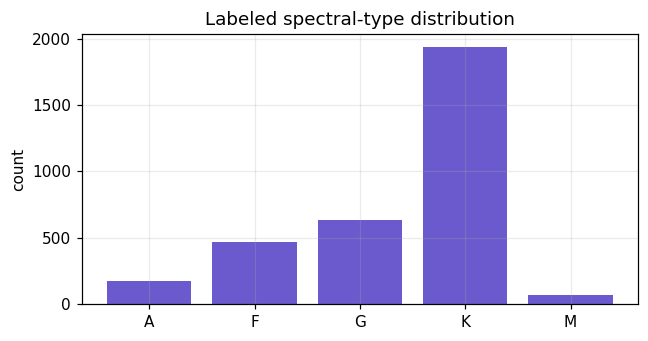

In [62]:
# Which spectral types do the VALIDATION labels contain?
type_counts = labeled_meta["SPECTRAL_TYPE"].value_counts()
print("Labeled-set spectral types (for external validation only):")
print(type_counts.to_string())
print(f"\nTotal labeled: {len(labeled_meta)} | distinct types: {type_counts.size}")
print(f"O stars: {(labeled_meta['SPECTRAL_TYPE'] == 'O').sum()} | "
      f"B stars: {(labeled_meta['SPECTRAL_TYPE'] == 'B').sum()}")
print(f"full_meta carries a SPECTRAL_TYPE column: "
      f"{'SPECTRAL_TYPE' in full_meta.columns}")

order = ["O", "B", "A", "F", "G", "K", "M"]
present = [t for t in order if t in type_counts.index]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(present, [type_counts.get(t, 0) for t in present], color="slateblue")
ax.set_title("Labeled spectral-type distribution")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# Step 0 - ETL (Extract, Transform, Load)

During preprocessing, we assigned `flux = 0.0` anywhere the instrument/data didn't cover or the continuum fit failed. If we passed those directly into `StandardScaler`, the scaler computes mean and standard deviation over both real flux and zeros. After scaling, padded bins become large negative values, and PCA then spends its leading components on whether a star has red-end coverage, and the anomaly detector would then flag coverage gaps instead of unusual stars.

We first measure the extent of the problem:
1. What fraction of stars have at least one zero bin?
2. For a typical star, how many zero bins are present, and how is that distributed?
3. Where on the wavelength grid does coverage fall off?
4. Is the pattern all-or-nothing padding, or a thin tail at the edges?


In [63]:
# Load the full flux block into RAM once for vectorized auditing.
flux = np.asarray(full_flux, dtype=np.float32)

is_zero = flux == 0
zero_counts = is_zero.sum(axis=1)            # zero bins per star
coverage_per_bin = (~is_zero).mean(axis=0)   # fraction of stars covering each bin

print(f"Stars with >=1 zero bin: {(zero_counts > 0).mean():.1%}")
print("Zero bins per star (percentiles):")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"   {p:3d}th pct: {np.percentile(zero_counts, p):6.0f} bins")

print(f"\nCoverage at bluest bin ({wave[0]:.0f} A):  {coverage_per_bin[0]:.1%}")
print(f"Coverage at reddest bin ({wave[-1]:.0f} A): {coverage_per_bin[-1]:.1%}")
print(f"Minimum per-bin coverage:                {coverage_per_bin.min():.1%}")
print(f"Bins with >=99% coverage: {(coverage_per_bin >= 0.99).sum():4d} / {len(wave)}")
print(f"Bins with >=95% coverage: {(coverage_per_bin >= 0.95).sum():4d} / {len(wave)}")

# Coverage exactly at the physically important absorption lines
print("\nCoverage at key absorption lines:")
for name, wl in ABSORPTION_LINES.items():
    b = int(np.argmin(np.abs(wave - wl)))
    print(f"   {name:7s} {wl:5d} A: {coverage_per_bin[b]:.1%}")

Stars with >=1 zero bin: 74.5%
Zero bins per star (percentiles):
    50th pct:      6 bins
    75th pct:     10 bins
    90th pct:     40 bins
    95th pct:     96 bins
    99th pct:    256 bins
   100th pct:    745 bins

Coverage at bluest bin (3622 A):  93.2%
Coverage at reddest bin (10354 A): 49.9%
Minimum per-bin coverage:                49.9%
Bins with >=99% coverage: 4139 / 4563
Bins with >=95% coverage: 4520 / 4563

Coverage at key absorption lines:
   Ca K     3933 A: 97.6%
   Ca H     3968 A: 98.3%
   Hgamma   4341 A: 99.8%
   Hbeta    4861 A: 100.0%
   Mg I     5175 A: 100.0%
   Na I     5893 A: 100.0%
   Halpha   6563 A: 99.9%
   Ca II    8542 A: 100.0%


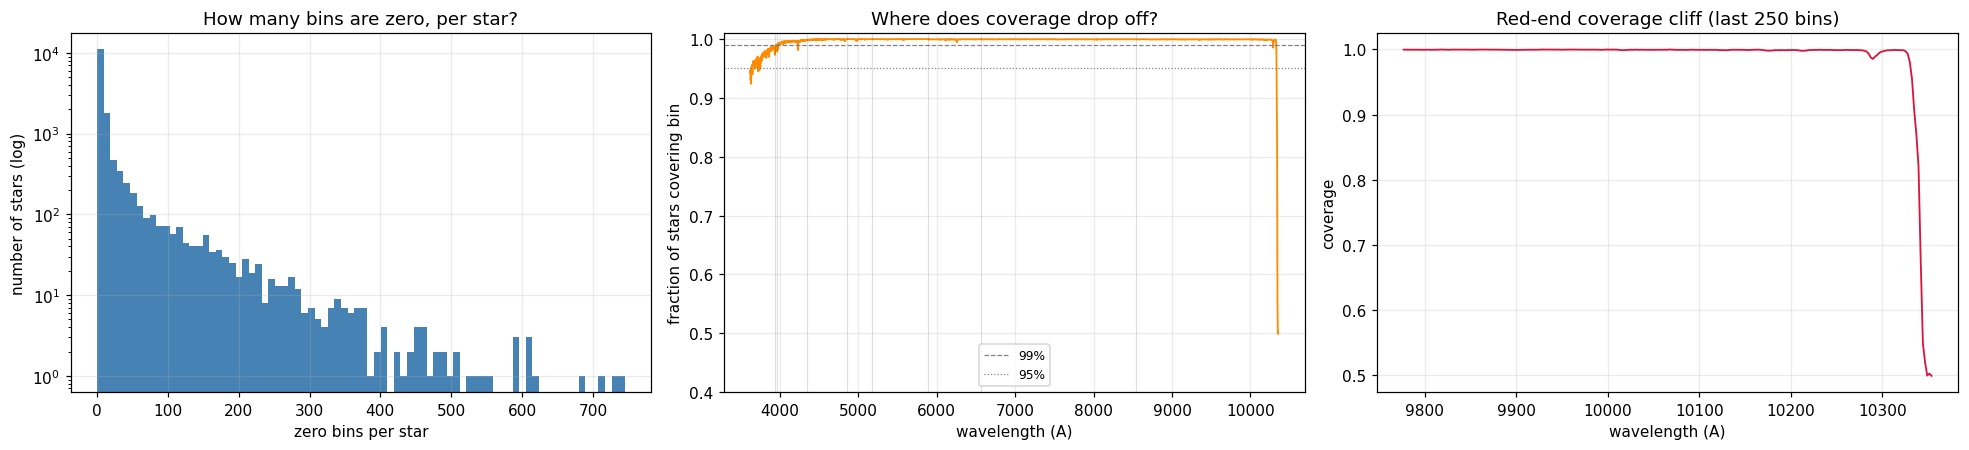

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))

# (1) Distribution of zero-bin counts per star (log y to see the heavy tail)
ax[0].hist(zero_counts, bins=80, color="steelblue")
ax[0].set_yscale("log")
ax[0].set_xlabel("zero bins per star")
ax[0].set_ylabel("number of stars (log)")
ax[0].set_title("How many bins are zero, per star?")

# (2) Coverage as a function of wavelength, with absorption lines and thresholds
ax[1].plot(wave, coverage_per_bin, color="darkorange", lw=1.2)
ax[1].axhline(0.99, ls="--", c="gray", lw=0.8, label="99%")
ax[1].axhline(0.95, ls=":", c="gray", lw=0.8, label="95%")
for name, wl in ABSORPTION_LINES.items():
    ax[1].axvline(wl, c="k", alpha=0.12, lw=0.8)
ax[1].set_xlabel("wavelength (A)")
ax[1].set_ylabel("fraction of stars covering bin")
ax[1].set_title("Where does coverage drop off?")
ax[1].set_ylim(0.4, 1.01)
ax[1].legend(loc="lower center", fontsize=8)

# (3) Zoom on the reddest 250 bins where the cliff lives
ax[2].plot(wave[-250:], coverage_per_bin[-250:], color="crimson", lw=1.2)
ax[2].set_xlabel("wavelength (A)")
ax[2].set_ylabel("coverage")
ax[2].set_title("Red-end coverage cliff (last 250 bins)")

plt.tight_layout()
plt.show()

### What the audit found and how we decided to clean the data

About **75% of stars have at least one zero bin**, so dropping entire stars isn't exactly practical without losing most of the sample. But most stars are only lightly affected, where the median is roughly 6 zero bins out of 4,563 (~0.1%). There is a heavy tail where the 95th percentile is about 96 bins and the maximum is about 745. Zeros are not scattered at random. Coverage is about 93% at the bluest bin, near 100% through most of the optical range, then drops sharply at the red end where only about 50% of stars have the reddest bin. There is also a smaller dip on the blue edge around Ca H and K (~3933 and 3968 A). So the pattern is edge-heavy padding plus sparse interior holes, not a simple all-or-nothing split.

Our original proposal was to run `StandardScaler` on continuum-normalized flux as-is, with no plan for zero bins, however a peer-reviewer had a great call-out that helped us out here. What our data analysis showed is a red-end cliff at roughly 50% coverage, a blue dip, and sparse holes in about 75% of stars. If we scaleed without fixing this, PCA would've learned coverage structure rather than temperature, similar to how distance metrics break down when the feature space includes padded values that are not physical measurements.

What we ended up doing is a two-step fix. 
First, keep bins with at least **95% coverage**. This cuts the red cliff and the worst blue and interior holes while keeping Ca H and K in the grid. A 99% threshold would've dropped that region, and those lines are temperature and gravity-sensitive, so that would have been worse for our goal. 
Secondly, for any remaining zeros in kept bins, impute with each bin's median over non-zero stars. After continuum normalization the flux is near 1.0, so we are basically putting the continuum level back rather than inventing spectral features.

We kept all stars this way; preserving the useful blue lines and stopped coverage from pretending to be physical signal. In Step 3 we can sensitivity-check the 95% cut by seeing whether PC loadings hit real absorption lines versus trimmed edges.


In [65]:
# (A) Trim to well-covered bins. Keep zero_counts on the FULL grid for failure analysis taht we can run later so we can tell data-quality anomalies from physical ones).
COVERAGE_THRESHOLD = 0.95
keep_bins = coverage_per_bin >= COVERAGE_THRESHOLD
wave_k = wave[keep_bins]
X = flux[:, keep_bins].copy()

print(f"Kept {keep_bins.sum()} / {len(wave)} bins "
      f"({keep_bins.sum() / len(wave):.1%}) covering {wave_k[0]:.0f}-{wave_k[-1]:.0f} A")
print(f"Dropped {(~keep_bins).sum()} bins (red-end cliff + blue/interior dropouts)")

# (B) Median impute residual zeros over non-zero stars.
zmask = X == 0
X_nan = np.where(zmask, np.nan, X)
bin_median = np.nanmedian(X_nan, axis=0).astype(np.float32)
bin_median = np.nan_to_num(bin_median, nan=1.0)   # safety for any all-zero bin
X[zmask] = np.broadcast_to(bin_median, X.shape)[zmask]
del X_nan

print(f"Imputed {zmask.sum():,} residual zero cells "
      f"({zmask.mean():.3%} of the retained matrix)")
print("Remaining zeros after imputation:", int((X == 0).sum()))

Kept 4520 / 4563 bins (99.1%) covering 3628-10332 A
Dropped 43 bins (red-end cliff + blue/interior dropouts)
Imputed 206,957 residual zero cells (0.301% of the retained matrix)
Remaining zeros after imputation: 0


# Step 1 - Exploratory data analysis

After handling coverage, we examined the spectra before further transformation or modeling:

1. **Flux distribution** - Normalized flux should cluster near 1.0. We look for preprocessing survivors: negative values and unreasonably large values.
2. **Mean spectrum +/- 1sigma** across all 15,200 stars, plus a random sample of individual spectra.
3. **Metadata** - PLATE and MJD (Modified Julian Date) spread, and whether coverage correlates with observation date (which would suggest systematic artifacts rather than random noise).


min flux:           0.000
max flux:           122,226.2   <- watch this
negative values:    0
     1.00th pct:    0.594
    50.00th pct:    1.001
    95.00th pct:    1.093
    99.00th pct:    1.307
    99.90th pct:    4.184
    99.99th pct:   68.127
values > 5:         58,180  (0.085%)
values > 10:        32,993  (0.0480%)


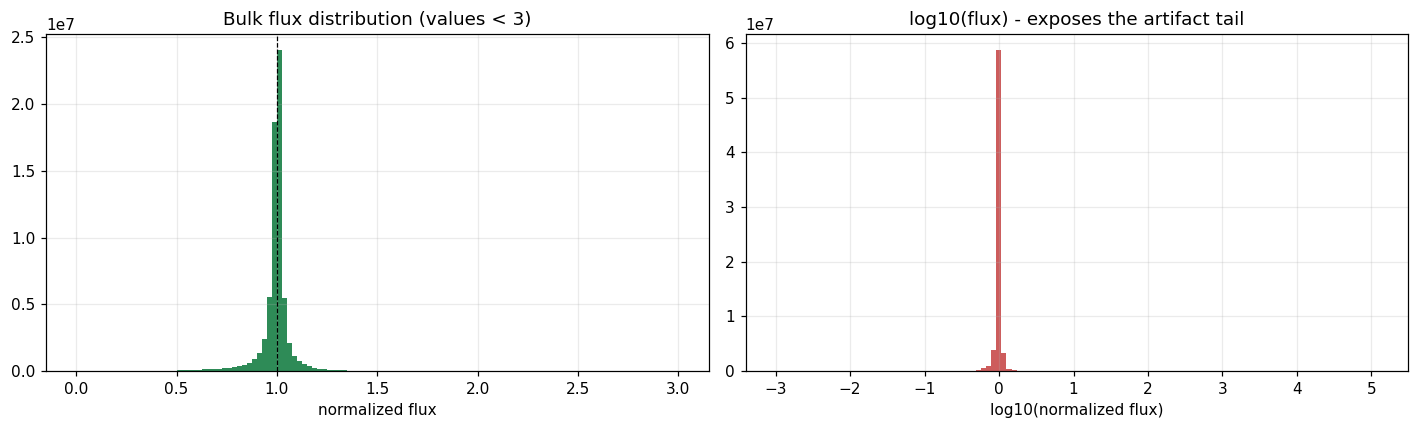

In [66]:
# Flux value distribution on the cleaned matrix
print(f"min flux:           {X.min():.3f}")
print(f"max flux:           {X.max():,.1f}   <- watch this")
print(f"negative values:    {(X < 0).sum()}")
for p in [1, 50, 95, 99, 99.9, 99.99]:
    print(f"   {p:6.2f}th pct: {np.percentile(X, p):8.3f}")
print(f"values > 5:         {(X > 5).sum():,}  ({(X > 5).mean():.3%})")
print(f"values > 10:        {(X > 10).sum():,}  ({(X > 10).mean():.4%})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(X[X < 3].ravel(), bins=120, color="seagreen")
ax[0].axvline(1.0, c="k", ls="--", lw=0.8)
ax[0].set_title("Bulk flux distribution (values < 3)")
ax[0].set_xlabel("normalized flux")

ax[1].hist(np.log10(np.clip(X[X > 0], 1e-3, None).ravel()), bins=120, color="indianred")
ax[1].set_title("log10(flux) - exposes the artifact tail")
ax[1].set_xlabel("log10(normalized flux)")
plt.tight_layout()
plt.show()

### Extreme flux values and clipping

Exploratory analysis turned up another issue we overlooked in the initial project proposal. Normalized flux should sit near ~1.0 (median ~ 1.00, 99th percentile ~ 1.3), but the maximum is on the order of 10^5. These are most likely not real stellar values, instead might be bad pixels divided by a near-zero continuum that slipped through preprocessing. One of those in a bin can dominate that bin's variance after `StandardScaler` and steal a PCA component. In addition, leaving them in could also cause randomized PCA to overflow.

Our fix is to clip flux to **[0, 10]**, which kills the artifact tail but stays above real strong emission (Halpha in Be stars is usually only a few times the continuum). We log how much got clipped for the report. The 10x upper bound is intentionally loose because we did not want to squash emission lines the anomaly detector should still catch.


In [67]:
CLIP_HI = 10.0
frac_clipped = (X > CLIP_HI).mean()
X = np.clip(X, 0.0, CLIP_HI)
print(f"Clipped {frac_clipped:.4%} of cells to [0, {CLIP_HI:g}]")
print(f"Post-clip flux range: [{X.min():.3f}, {X.max():.3f}], median {np.median(X):.3f}")

Clipped 0.0480% of cells to [0, 10]
Post-clip flux range: [0.000, 10.000], median 1.001


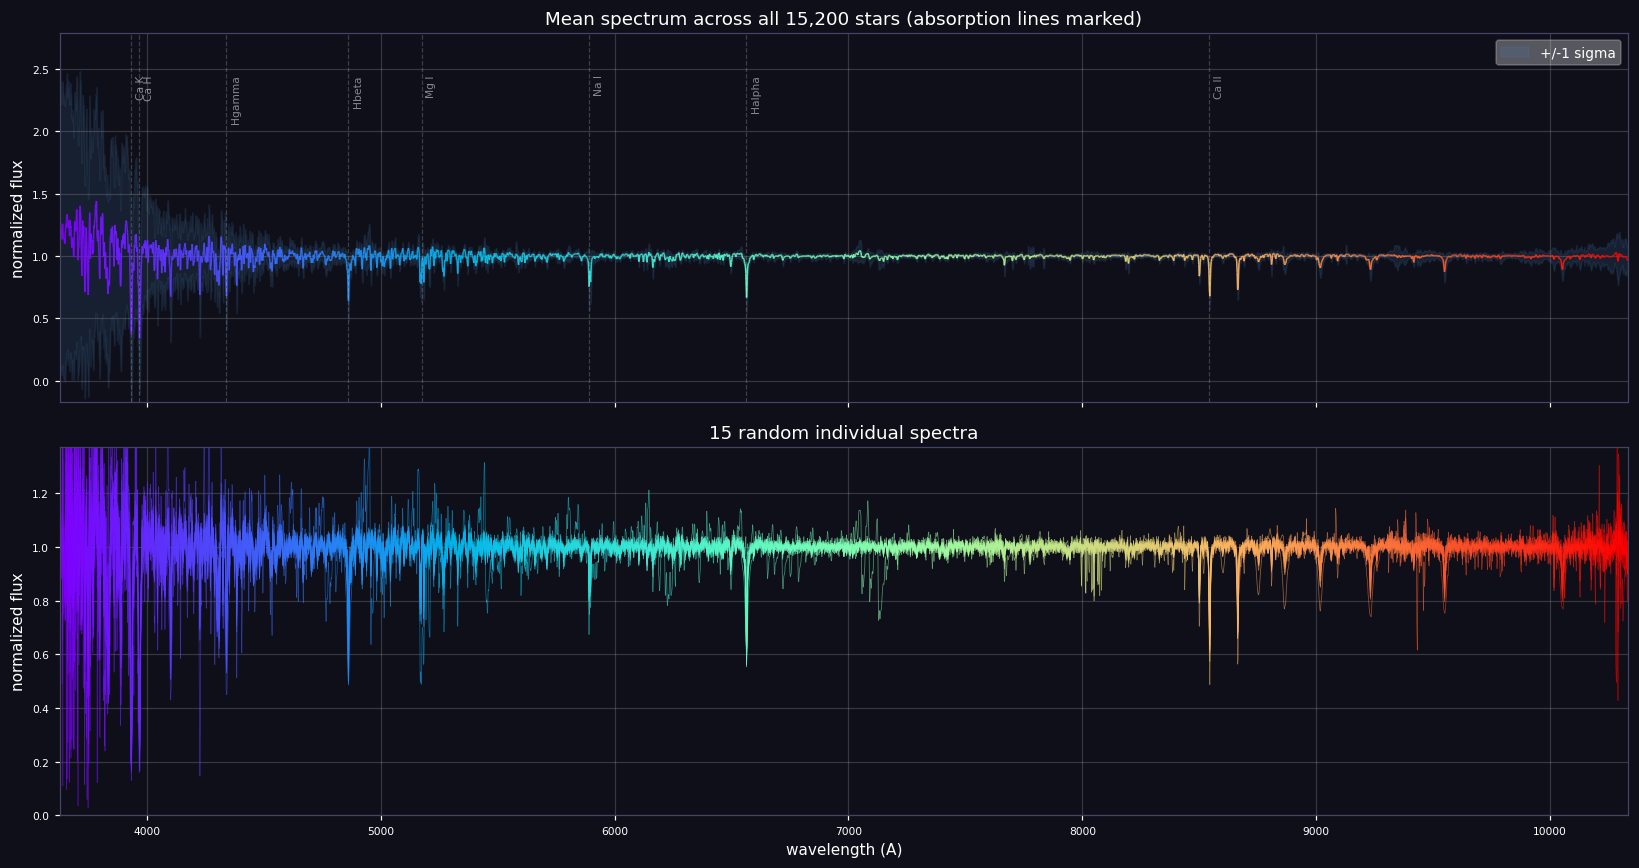

In [68]:
from matplotlib.collections import LineCollection

# Mean spectrum with +/-1 sigma envelope, and a random sample of individual spectra
mean_spec = X.mean(axis=0)
std_spec = X.std(axis=0)

rng = np.random.default_rng(RANDOM_STATE)
sample_rows = rng.choice(X.shape[0], 15, replace=False)

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.patch.set_facecolor('#0f0f1a')
norm = plt.Normalize(wave_k.min(), wave_k.max())

ax[0].set_facecolor('#0f0f1a')
pts = np.array([wave_k, mean_spec]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', norm=norm, linewidth=1.0, alpha=0.9)
lc.set_array(wave_k)
ax[0].add_collection(lc)
ax[0].fill_between(wave_k, mean_spec - std_spec, mean_spec + std_spec,
                   color='steelblue', alpha=0.15, label="+/-1 sigma")
ax[0].set_xlim(wave_k[0], wave_k[-1])
ax[0].set_ylim((mean_spec - std_spec).min() * 0.9, (mean_spec + std_spec).max() * 1.1)
for name, wl in ABSORPTION_LINES.items():
    if wave_k[0] < wl < wave_k[-1]:
        ax[0].axvline(wl, c='white', alpha=0.2, lw=0.8, ls='--')
        ax[0].text(wl + 20, (mean_spec + std_spec).max() * 0.97, name, fontsize=7,
                   rotation=90, va='top', alpha=0.5, color='white')
ax[0].set_ylabel("normalized flux", color='white')
ax[0].set_title("Mean spectrum across all 15,200 stars (absorption lines marked)", color='white')
ax[0].tick_params(colors='white', labelsize=7)
ax[0].legend(loc="upper right", fontsize=9, labelcolor='white', framealpha=0.3)
for spine in ax[0].spines.values():
    spine.set_edgecolor('#444466')

ax[1].set_facecolor('#0f0f1a')
for r in sample_rows:
    y = X[r]
    pts = np.array([wave_k, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap='rainbow', norm=norm, linewidth=0.5, alpha=0.55)
    lc.set_array(wave_k)
    ax[1].add_collection(lc)
ax[1].set_xlim(wave_k[0], wave_k[-1])
ax[1].set_ylim(0, np.percentile(X[sample_rows], 99.5) * 1.1)
ax[1].set_ylabel("normalized flux", color='white')
ax[1].set_xlabel("wavelength (A)", color='white')
ax[1].set_title("15 random individual spectra", color='white')
ax[1].tick_params(colors='white', labelsize=7)
for spine in ax[1].spines.values():
    spine.set_edgecolor('#444466')

plt.tight_layout()
plt.show()

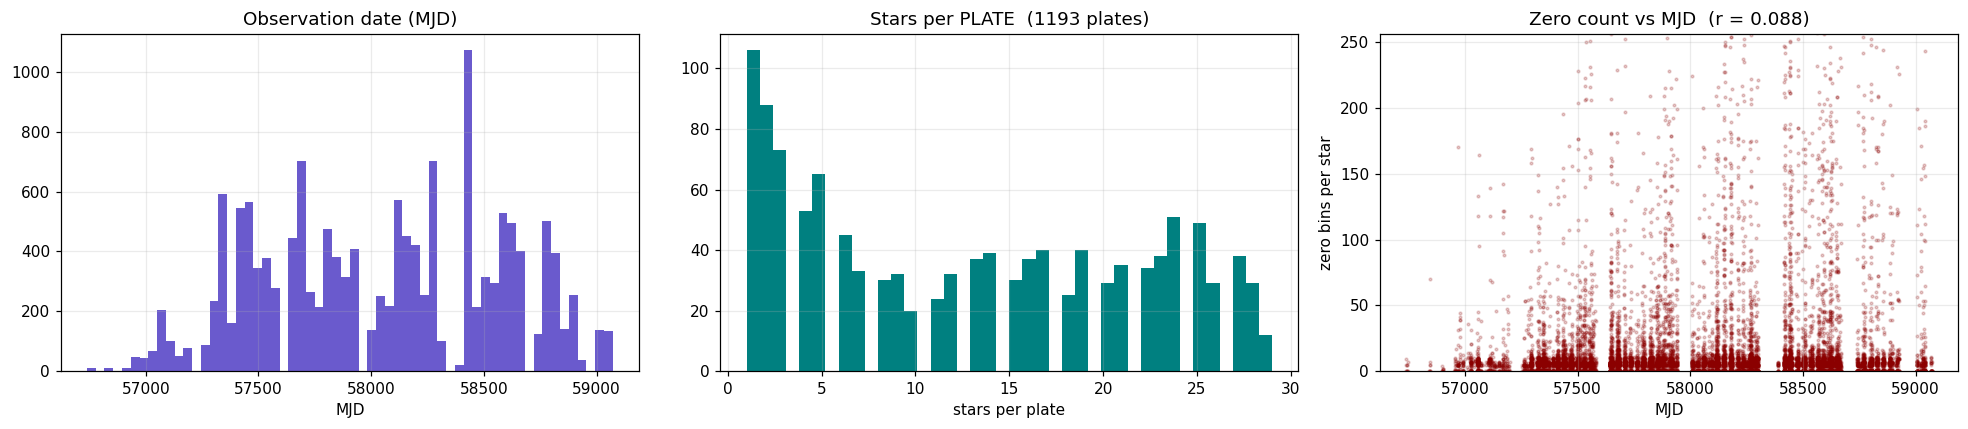

Correlation(zero-bin count, MJD) = 0.088 -> weak; coverage loss is not strongly tied to observation date.


In [69]:
# Metadata distributions + is the coverage artifact tied to when/where it was observed?
mjd = full_meta["MJD"].to_numpy()
corr_cov_mjd = np.corrcoef(zero_counts, mjd)[0, 1]

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(mjd, bins=60, color="slateblue")
ax[0].set_title("Observation date (MJD)")
ax[0].set_xlabel("MJD")

plate_counts = full_meta["PLATE"].value_counts()
ax[1].hist(plate_counts.values, bins=40, color="teal")
ax[1].set_title(f"Stars per PLATE  ({full_meta['PLATE'].nunique()} plates)")
ax[1].set_xlabel("stars per plate")

ax[2].scatter(mjd, zero_counts, s=3, alpha=0.2, color="darkred")
ax[2].set_title(f"Zero count vs MJD  (r = {corr_cov_mjd:.3f})")
ax[2].set_xlabel("MJD")
ax[2].set_ylabel("zero bins per star")
ax[2].set_ylim(0, np.percentile(zero_counts, 99))
plt.tight_layout()
plt.show()

print(f"Correlation(zero-bin count, MJD) = {corr_cov_mjd:.3f} "
      "-> weak; coverage loss is not strongly tied to observation date.")

# Step 2 - StandardScaler

Now that we applied continuum normalization to remove each star's absolute brightness (distance, dust, throughput, etc) we can now compare spectral *shape*.
**StandardScaler** will be used to equalize the per-wavelength variance across the population, so that a naturally variable region (for example, a deep absorption line) doesn't dominate the PCA simply because it has high variance.

We saved the fitted scaler so that the same transform can be applied later too, for example when processing labeled stars for validation.


In [70]:
scaler = StandardScaler()
Z = scaler.fit_transform(X.astype(np.float64))
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)

# Near-constant bins get a tiny scale, which can inflate their standardized values to huge magnitudes and destabilize or even overflows randomized PCA. 
# Winsorize to +/-10 sigma so that downstream PCA is more numerically robust.
frac_winsorized = float(np.mean(np.abs(Z) > 10))
X_scaled = np.clip(Z, -10, 10).astype(np.float32)
del Z

print("Scaled matrix:", X_scaled.shape)
print(f"Winsorized {frac_winsorized:.4%} of cells to +/-10 sigma "
      "(degenerate low-variance bins)")
print("zero-variance bins:", int((scaler.scale_ == 0).sum()))

Scaled matrix: (15200, 4520)
Winsorized 0.0670% of cells to +/-10 sigma (degenerate low-variance bins)
zero-variance bins: 0


# Step 3 - PCA

PCA (Principal Component Analysis) serves two roles here: **compression** and **diagnostics**. 
For compression, we need to project 4,520-dimensional standardized spectra into a lower-dimensional space before clustering and anomaly detection. Otherwise distance and density metrics would degrade quickly in high dimensions. 
Diagnostically, this also gives us a sanity check that the model is responding to stellar physics rather than to the pure data artifacts themselves, by using the loading patterns on wavelength to reveal the physical variations each component captures.

**Choosing the number of components.** After `StandardScaler`, the cumulative variance curve rises slowly with no obvious elbow because every wavelength bin has unit variance. We used four complementary methods to determine the cut-off.

- Scree plot and cumulative variance
- Parallel analysis
- Broken-stick null
- Full eigenspectrum

We first fit 200 PCs as a diagnostic decomposition proxy, since that should be enough to test all 4 methods to start with and get a sense of the decay.

Spectral types trace a curved path through feature space (M -> K -> G -> F -> A), not a straight line, so PCA components will not correspond directly to Teff, log g, or [Fe/H]. What we do expect is that PC1 loads on temperature-sensitive features like Halpha and Ca K, and that later PCs pick up gravity and metallicity effects.

*(Note: `svd_solver="covariance_eigh"` forms X.T @ X internally and is deterministic and fast when n_samples >> n_features.)*

PC1 explains 22.2% of variance
First 3 PCs explain 38.7%
Variance at 200 PCs: 68.2%


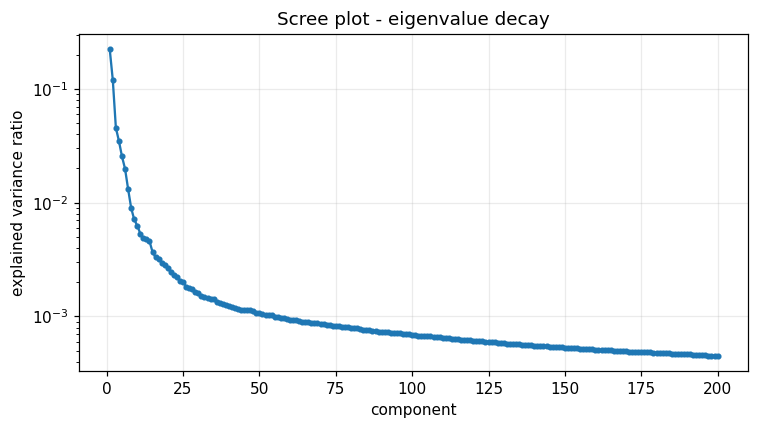

In [71]:
# Fit 200 PCs for diagnostics; the same decomposition powers the principled
# dimensionality selection below. Float64 prevents spurious BLAS overflow warnings.
N_COMPONENTS = 200
pca_full = PCA(n_components=N_COMPONENTS, svd_solver="covariance_eigh")
with np.errstate(all="ignore"):
    scores = pca_full.fit_transform(X_scaled.astype(np.float64))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

print(f"PC1 explains {pca_full.explained_variance_ratio_[0]:.1%} of variance")
print(f"First 3 PCs explain {cumvar[2]:.1%}")
print(f"Variance at {N_COMPONENTS} PCs: {cumvar[-1]:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, N_COMPONENTS + 1), pca_full.explained_variance_ratio_, "o-", ms=3)
ax.set_title("Scree plot - eigenvalue decay")
ax.set_xlabel("component"); ax.set_ylabel("explained variance ratio")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

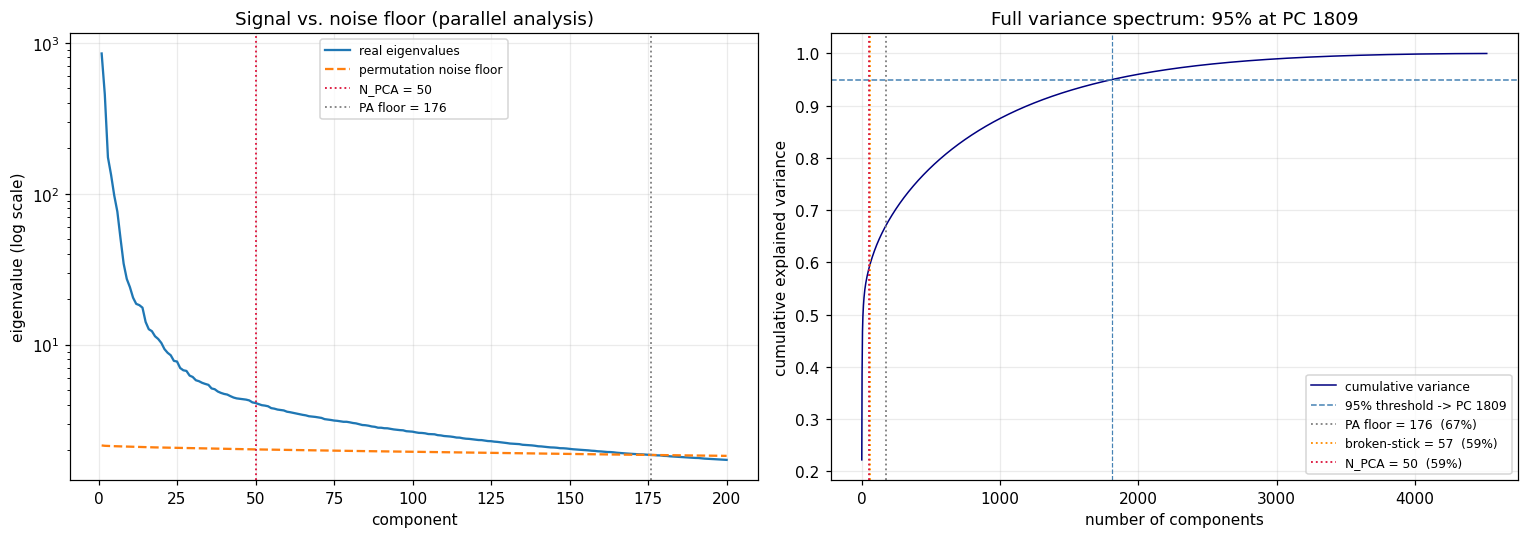

Signal boundary: broken-stick = 57 PCs | parallel analysis = 176 PCs
95% variance requires 1809 components - 1633 beyond the signal floor.
Working compression: N_PCA = 50 (59% variance).


In [72]:
# Principled dimensionality selection
from numpy.random import default_rng
rng = default_rng(RANDOM_STATE)

real_eig = pca_full.explained_variance_[:N_COMPONENTS]
Xs64 = X_scaled.astype(np.float64)

# Parallel analysis: column permutations mess up inter-bin covariance, leaving the noise floor. Values above it are what we'd keep or deem significant.
noise_eig = np.zeros(N_COMPONENTS)
N_REP = 3
with np.errstate(all="ignore"):
    for _ in range(N_REP):
        idx = np.argsort(rng.random(Xs64.shape), axis=0)
        Xperm = np.take_along_axis(Xs64, idx, axis=0)
        noise_eig += PCA(n_components=N_COMPONENTS, svd_solver="covariance_eigh").fit(Xperm).explained_variance_
noise_eig /= N_REP
n_parallel = int(np.argmax(real_eig < noise_eig))

# Broken-stick null: the expected eigenvalue distribution if the variance were randomly distributed across all dimensions.
p_feat = X_scaled.shape[1]
bstick = np.array([np.sum(1.0 / np.arange(k, p_feat + 1)) / p_feat for k in range(1, N_COMPONENTS + 1)])
n_bstick = int(np.argmax(pca_full.explained_variance_ratio_[:N_COMPONENTS] < bstick))

# Full eigenspectrum: all p eigenvalues of the sample covariance matrix.
from scipy.linalg import eigvalsh as _sp_eigvalsh
_C = (Xs64.T @ Xs64) / (Xs64.shape[0] - 1)
_all_eig = _sp_eigvalsh(_C)[::-1]
del _C
_all_eig = np.maximum(_all_eig, 0)
_all_evr = _all_eig / _all_eig.sum()
all_cumvar_full = np.cumsum(_all_evr)
n95_actual = int(np.searchsorted(all_cumvar_full, 0.95)) + 1
del _all_eig, _all_evr

# Working compression: below the broken-stick conservative signal boundary
N_PCA = 50
X_pca50 = scores[:, :N_PCA]
X_pca = X_pca50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: real eigenvalues vs permutation noise floor
axes[0].plot(range(1, N_COMPONENTS + 1), real_eig, label="real eigenvalues")
axes[0].plot(range(1, N_COMPONENTS + 1), noise_eig, "--", label="permutation noise floor")
axes[0].axvline(N_PCA, c="crimson", ls=":", lw=1.2, label=f"N_PCA = {N_PCA}")
axes[0].axvline(n_parallel, c="gray", ls=":", lw=1.2, label=f"PA floor = {n_parallel}")
axes[0].set_yscale("log")
axes[0].set_xlabel("component"); axes[0].set_ylabel("eigenvalue (log scale)")
axes[0].set_title("Signal vs. noise floor (parallel analysis)")
axes[0].legend(fontsize=8)

# Right: full cumulative variance with all criteria marked
axes[1].plot(range(1, p_feat + 1), all_cumvar_full, lw=1.0, color="navy",
             label="cumulative variance")
axes[1].axhline(0.95, ls="--", c="steelblue", lw=1.0,
                label=f"95% threshold -> PC {n95_actual}")
axes[1].axvline(n95_actual, ls="--", c="steelblue", lw=0.8)
axes[1].axvline(n_parallel, ls=":", c="gray", lw=1.2,
                label=f"PA floor = {n_parallel}  ({all_cumvar_full[n_parallel-1]:.0%})")
axes[1].axvline(n_bstick, ls=":", c="darkorange", lw=1.2,
                label=f"broken-stick = {n_bstick}  ({all_cumvar_full[n_bstick-1]:.0%})")
axes[1].axvline(N_PCA, ls=":", c="crimson", lw=1.2,
                label=f"N_PCA = {N_PCA}  ({all_cumvar_full[N_PCA-1]:.0%})")
axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative explained variance")
axes[1].set_title(f"Full variance spectrum: 95% at PC {n95_actual}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Signal boundary: broken-stick = {n_bstick} PCs | parallel analysis = {n_parallel} PCs")
print(f"95% variance requires {n95_actual} components - {n95_actual - n_parallel} beyond the signal floor.")
print(f"Working compression: N_PCA = {N_PCA} ({all_cumvar_full[N_PCA-1]:.0%} variance).")

### Reading the dimensionality comparison

The real eigenvalues drop below the noise floor on the left panel at a certain point. This point is where components start to look like noise rather than actual variations in star properties like temperature, gravity, or metallicity. Beyond this point, components are statistically indistinguishable from noise and tend to encode instrument throughput and wavelength-coverage gradients rather than inter-star variation.

Roughly 90% of components that capture 95% of the variance are below the noise floor. This shows that using variance to decide on the number of components isn't very reliable, as the right panel places the 95% variance threshold on the same axis, and it falls well past the signal boundary. The broken-stick null model gives a conservative lower estimate of the signal boundary at 57 components.

We use **N_PCA = 50** components, which is just below this threshold. Components 51-57 might reflect instrument quirks rather than star properties. Using 50 components provides a clear signal for all analysis methods. This includes k-means, HDBSCAN, UMAP, and anomaly detection. We've checked that our cluster assignments are stable across many dimensions through the clustering ablation in Step 4. We've also found the best number of dimensions for detecting anomalies through the anomaly detection ablation in Step 5. The same 50-dimensional space is used for all methods so every method is compared on equal footing.

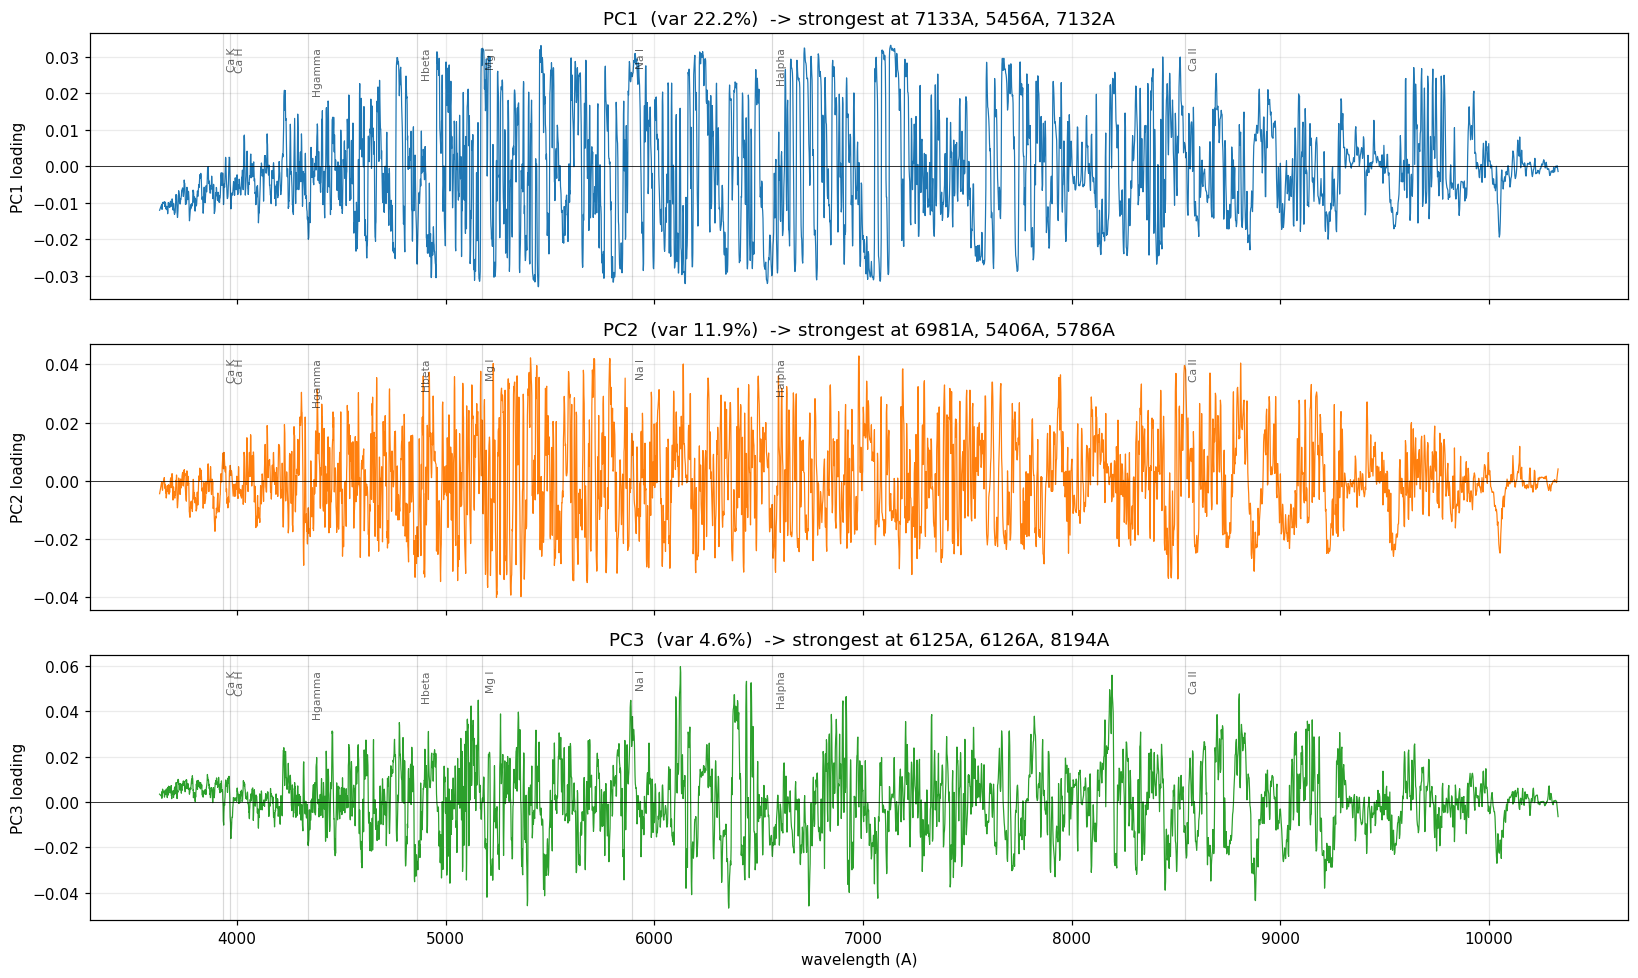

In [73]:
# Feature importance proxy: project the first 3 component loadings back onto wavelength.
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for i, axi in enumerate(axes):
    load = pca_full.components_[i]
    axi.plot(wave_k, load, lw=0.8, color=f"C{i}")
    axi.axhline(0, c="k", lw=0.5)
    for name, wl in ABSORPTION_LINES.items():
        if wave_k[0] < wl < wave_k[-1]:
            axi.axvline(wl, c="k", alpha=0.15, lw=0.8)
            axi.text(wl + 20, axi.get_ylim()[1] * 0.9, name, fontsize=7,
                     rotation=90, va="top", alpha=0.6)
    # annotate the 3 strongest-loading wavelengths
    top = np.argsort(np.abs(load))[::-1][:3]
    peaks = ", ".join(f"{wave_k[t]:.0f}A" for t in top)
    axi.set_ylabel(f"PC{i + 1} loading")
    axi.set_title(f"PC{i + 1}  (var {pca_full.explained_variance_ratio_[i]:.1%})  "
                  f"-> strongest at {peaks}")
axes[-1].set_xlabel("wavelength (A)")
plt.tight_layout()
plt.show()

**How to interpret the loadings:**

 - PC1 represents temperature. Driven by the continuum slope and specific wavelengths, Halpha at 6563 A and Ca K at 3933 A, these are key factors that vary across different spectral types. 
 - PC2 and beyond are more about gravity and metallicity. They load on wavelengths like Mg I 5175, Na I 5893, and Ca II 8542. 
 - If a principal component shows a spike at the edges of the trimmed wavelengths without a nearby absorption line, it's likely an artifact.

# Step 4 - Clustering

We applied two clustering approaches to the 50-D PCA representation: **k-means** and **HDBSCAN**.

k-means partitions stars into K groups by minimizing within-cluster variance. It is fast and interpretable, and provides a hard assignment for every star, which is why we initially suggested it in the proposal. Its main limitation however is that it assumes spherical, equally-sized clusters - which after some research we found to be a suboptimal fit for stellar populations, where the main sequence is a continuous diagonal streak through Teff-log g space and the giant branch forms a separate lobe. However, we still ran a full K sweep from 2 to 15 using three independent metrics (inertia elbow, silhouette score, Davies-Bouldin index) and report all three to avoid overfitting to any single criterion. 

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) requires no K, handles elongated and non-convex cluster shapes, and assigns ambiguous points to a noise class rather than forcing membership. A large noise fraction is itself useful information; it indicates the data form a continuous sequence rather than discrete blobs, which is the physically expected structure for a smooth spectral-type sequence. 

We compare both methods on the Kiel diagram in Step 6 to emperically assess which approach better aligns with known stellar groups.

K= 2  inertia=    23729138  silhouette=0.551  davies-bouldin=1.110
K= 3  inertia=    18580277  silhouette=0.427  davies-bouldin=1.175
K= 4  inertia=    16491733  silhouette=0.380  davies-bouldin=1.107
K= 5  inertia=    14514640  silhouette=0.387  davies-bouldin=1.154
K= 6  inertia=    13220661  silhouette=0.390  davies-bouldin=1.129
K= 7  inertia=    12070819  silhouette=0.244  davies-bouldin=1.223
K= 8  inertia=    11143347  silhouette=0.270  davies-bouldin=1.171
K= 9  inertia=    10427519  silhouette=0.271  davies-bouldin=1.213
K=10  inertia=     9793460  silhouette=0.271  davies-bouldin=1.159
K=11  inertia=     9220879  silhouette=0.266  davies-bouldin=1.168
K=12  inertia=     8849005  silhouette=0.267  davies-bouldin=1.103
K=13  inertia=     8552211  silhouette=0.213  davies-bouldin=1.194
K=14  inertia=     8266622  silhouette=0.203  davies-bouldin=1.192
K=15  inertia=     7990309  silhouette=0.200  davies-bouldin=1.210


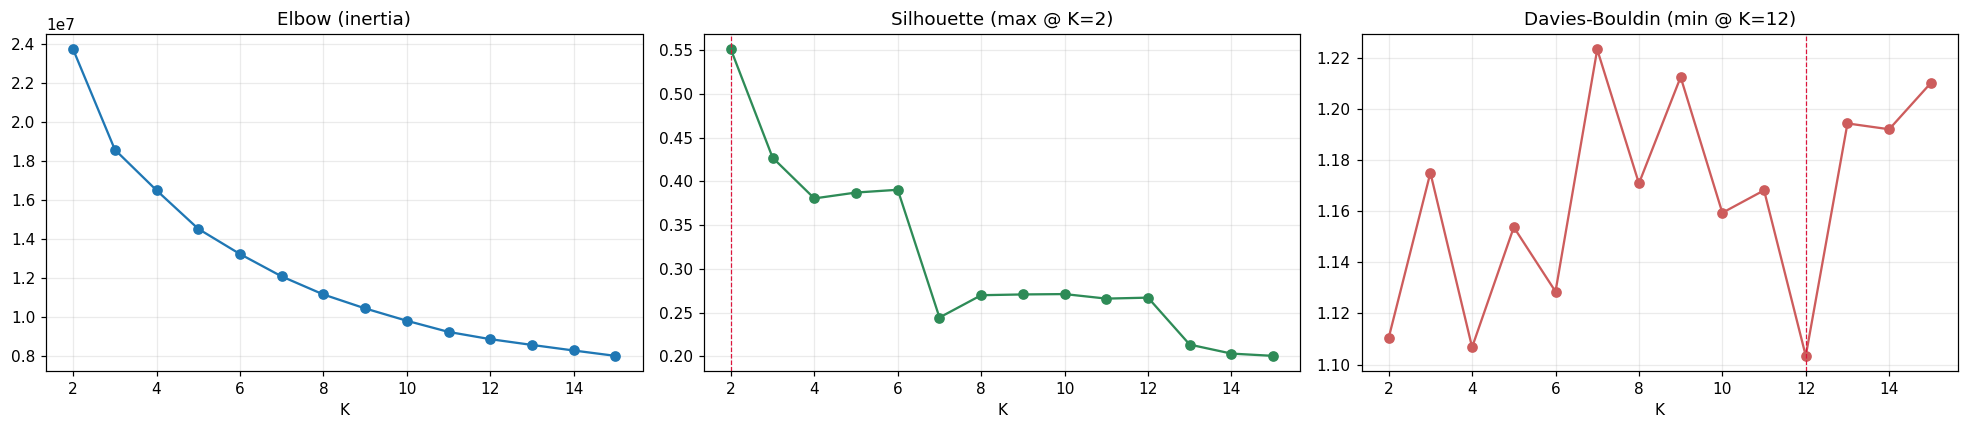


Silhouette favors K=2; Davies-Bouldin favors K=12.


In [74]:
K_range = list(range(2, 16))
inertia, silhouette, davies = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_pca50)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca50, labels_k,
                                       sample_size=5000, random_state=RANDOM_STATE))
    davies.append(davies_bouldin_score(X_pca50, labels_k))
    print(f"K={k:2d}  inertia={km.inertia_:12.0f}  "
          f"silhouette={silhouette[-1]:.3f}  davies-bouldin={davies[-1]:.3f}")

best_sil_K = K_range[int(np.argmax(silhouette))]
best_db_K = K_range[int(np.argmin(davies))]

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(K_range, inertia, "o-"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(K_range, silhouette, "o-", color="seagreen")
ax[1].axvline(best_sil_K, ls="--", c="crimson", lw=0.8)
ax[1].set_title(f"Silhouette (max @ K={best_sil_K})")
ax[2].plot(K_range, davies, "o-", color="indianred")
ax[2].axvline(best_db_K, ls="--", c="crimson", lw=0.8)
ax[2].set_title(f"Davies-Bouldin (min @ K={best_db_K})")
for a in ax:
    a.set_xlabel("K")
plt.tight_layout()
plt.show()
print(f"\nSilhouette favors K={best_sil_K}; Davies-Bouldin favors K={best_db_K}.")

### Choosing K

The three metrics often disagree on a streaky manifold like the main sequence. Silhouette tends to favor the smallest K because the cleanest split is the binary warm-versus-cool axis - a real and meaningful distinction, but coarse. Larger K (5-6, sometimes a secondary silhouette peak) separates finer spectral types at the cost of lower silhouette. The elbow and Davies-Bouldin index sometimes point toward an intermediate K. But a K that aligns with coherent stellar groups is probably more useful than one that maximizes a scalar metric alone.

The next cell sets `K_FINAL` from the silhouette peak. A finer K is also fit below for interpretation.

In [75]:
# Default to the silhouette-optimal K
K_FINAL = best_sil_K
print(f"Using K_FINAL = {K_FINAL}")

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca50)   # same PCA-50 space as HDBSCAN / UMAP

sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("Cluster sizes:")
for c, n in sizes.items():
    print(f"   cluster {c}: {n:5d} stars ({n / len(cluster_labels):.1%})")

Using K_FINAL = 2
Cluster sizes:
   cluster 0: 13274 stars (87.3%)
   cluster 1:  1926 stars (12.7%)


In [76]:
# HDBSCAN alternative on the 50-D PCA projection (no K required).
try:
    import hdbscan
    clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=10)
    hdb_labels = clusterer.fit_predict(X_pca50)
    n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    noise_frac = (hdb_labels == -1).mean()
    print(f"HDBSCAN found {n_hdb} clusters; {noise_frac:.1%} of stars labeled noise.")
    print("HDBSCAN cluster sizes:")
    print(pd.Series(hdb_labels).value_counts().sort_index().to_string())
except ImportError:
    hdb_labels = None
    print("hdbscan not installed; skipping. On Colab: !pip install hdbscan")

HDBSCAN found 2 clusters; 47.0% of stars labeled noise.
HDBSCAN cluster sizes:
-1    7144
 0    7704
 1     352


**Comparing k-means and HDBSCAN.** k-means produces `K_FINAL` clusters of roughly similar size and assigns every star, including outliers. HDBSCAN finds density peaks and marks ambiguous spectra as noise. A large noise fraction suggests the data form one continuous temperature sequence rather than separate blobs. Compare cluster counts and assess which method aligns better with Kiel diagram groups in Step 6.


### Ablation - do representation choices affect clustering?

1. **PCA dimensionality** - Re-cluster at `K_FINAL` using 10, 30, 50, and 100 components. Compare Adjusted Rand Index (ARI) to the 50-D baseline. High ARI means clustering is stable under compression.
2. **Remove the blue Ca H and K region (<4200 A)** - Take the region we retained by using 95% coverage in Step 0, and drop, re-scale, re-PCA, re-cluster, and compare ARI to the full spectrum to see how our choices affected our model outputs. Low ARI means blue lines drive clustering; high ARI means the coarse warm/cool split does not depend on them (blue lines may still matter for finer gravity and metallicity structure).

In [77]:
from sklearn.metrics import adjusted_rand_score

# Ablation 1: cluster stability vs PCA dimensionality (ARI vs the PCA-50 solution).
print("ABLATION 1 - cluster stability vs PCA dimensionality:")
abl_rows = []
for d in [10, 30, 50, 100]:
    Xd = scores[:, :d]
    lab_d = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE,
                   n_init=10).fit_predict(Xd)
    abl_rows.append({
        "pca_dims": d,
        "silhouette": round(float(silhouette_score(
            Xd, lab_d, sample_size=5000, random_state=RANDOM_STATE)), 3),
        "ARI_vs_pca50": round(float(adjusted_rand_score(cluster_labels, lab_d)), 3),
    })
print(pd.DataFrame(abl_rows).to_string(index=False))

# Ablation 2: does the blue Ca H&K block (<4200 A) materially change the clusters?
print("\nABLATION 2 - drop the blue Ca H&K block (<4200 A) and re-cluster:")
blue = wave_k < 4200
Xs_noblue = StandardScaler().fit_transform(X[:, ~blue].astype(np.float64))
Xs_noblue = np.nan_to_num(Xs_noblue, nan=0.0, posinf=0.0, neginf=0.0)
Xs_noblue = np.clip(Xs_noblue, -10, 10).astype(np.float32)   # same winsorize as Step 2
pca_nb = PCA(n_components=50, svd_solver="covariance_eigh")
lab_nb = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE,
                n_init=10).fit_predict(pca_nb.fit_transform(Xs_noblue))
print(f"Dropped {int(blue.sum())} blue bins (<4200 A, incl. Ca H&K).")
print(f"ARI(full vs no-blue) = {adjusted_rand_score(cluster_labels, lab_nb):.3f}")

ABLATION 1 - cluster stability vs PCA dimensionality:
 pca_dims  silhouette  ARI_vs_pca50
       10       0.594           1.0
       30       0.558           1.0
       50       0.551           1.0
      100       0.544           1.0

ABLATION 2 - drop the blue Ca H&K block (<4200 A) and re-cluster:
Dropped 610 blue bins (<4200 A, incl. Ca H&K).
ARI(full vs no-blue) = 0.981


### What the ablations show

**Ablation 1** (dimensionality stability): Cluster assignments are identical across 10, 30, 50, and 100 PCs (ARI = 1.0 throughout). The K = 2 warm/cool split is driven entirely by the dominant temperature axis captured in the first few components; adding or removing later PCs does not change which stars end up together. However we had to be aware that this finding does not automatically carry over to anomaly detection, as anomaly detection is sensitive to the geometry of the full feature space - we tested this separately in the Step 5 ablation tests.

**Ablation 2** (Ca H and K sensitivity): Removing the 610-bin blue region below 4200 A gives ARI = 0.981 - the two clusters are nearly unchanged. The coarse warm/cool boundary is set by continuum color, not by specific absorption features. Ca H and K likely matter for finer spectral structure (metallicity, gravity effects visible at K = 6) but do not determine the dominant split.

**Caveat**: ARI near 1.0 at K = 2 is partly expected. A binary warm/cool partition is easy to reproduce from almost any spectral region, so high ARI is a relatively weak robustness claim at this granularity.

### Checking clusters against labeled stars

About 3,291 labeled stars were **not** included in the fit. This lets us match by MANGAID (the MaNGA survey unique star identifier), see which cluster each star received, and plot results on the **Kiel diagram** (Teff versus log g). If a cluster does not correspond to a coherent stellar group, it could be an interesting finding to be called out.


Matched 3291 / 3291 labeled stars into the full set.

Cluster x spectral type (labeled stars):
SPECTRAL_TYPE    A    F    G     K   M
cluster                               
0              179  470  632  1784   1
1                0    0    2   152  71

Mean Teff per cluster (labeled stars):
cluster
0    5307.0
1    3844.0


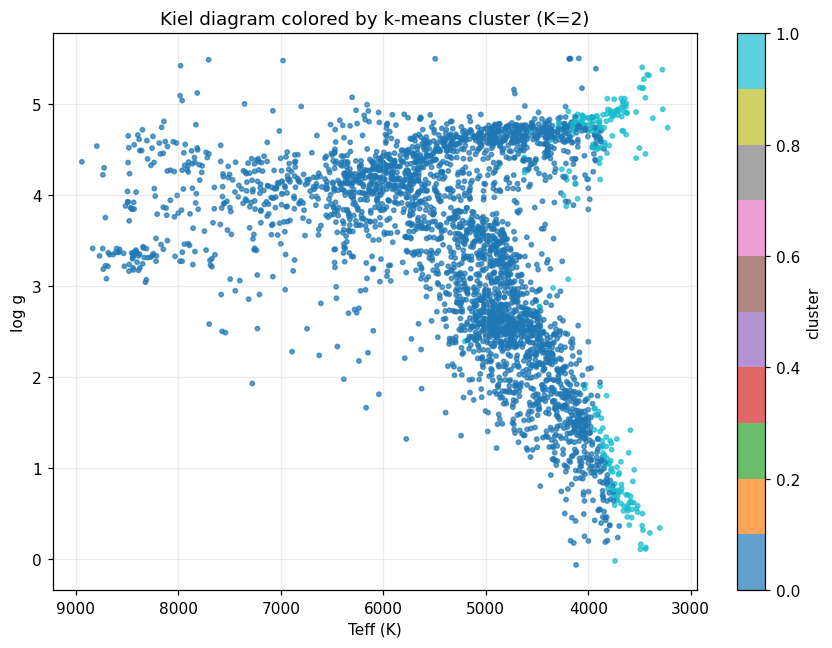

In [78]:
# Map each labeled star to its row in the full (unsupervised) set via MANGAID.
id_to_row = {mid: i for i, mid in enumerate(full_meta["MANGAID"].to_numpy())}
val = labeled_meta.copy()
val["row"] = val["MANGAID"].map(id_to_row)
val = val[val["row"].notna()].copy()
val["row"] = val["row"].astype(int)
val["cluster"] = cluster_labels[val["row"].to_numpy()]
print(f"Matched {len(val)} / {len(labeled_meta)} labeled stars into the full set.")

# Crosstab: do clusters line up with spectral type? + mean Teff per cluster.
ct = pd.crosstab(val["cluster"], val["SPECTRAL_TYPE"])
print("\nCluster x spectral type (labeled stars):")
print(ct.to_string())
print("\nMean Teff per cluster (labeled stars):")
print(val.groupby("cluster")["INPUT_TEFF"].mean().round(0).to_string())

# Kiel diagram colored by cluster assignment.
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(val["INPUT_TEFF"], val["INPUT_LOGG"], c=val["cluster"],
                cmap="tab10", s=8, alpha=0.7)
ax.invert_xaxis()
ax.set_xlabel("Teff (K)"); ax.set_ylabel("log g")
ax.set_title(f"Kiel diagram colored by k-means cluster (K={K_FINAL})")
plt.colorbar(sc, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

### Finer K for interpretability

Silhouette's `K_FINAL = 2` gives a valid but high-level **warm versus cool** split. At this granularity, the Category B "mis-clustered" example is probably not a clear misassignment, rather it could be a murky middle area between temperature ranges. 
Therefore, we also fit `K_FINE = 6` and compare it to labels. K = 6 scored lower on silhouette but separates groups that K = 2 merges - for example, a hot A/F cluster and a cool M cluster. K = 2 remains the primary result; K = 6 is for interpretation only and is not used in anomaly detection or failure analysis.


K=6 cluster sizes (full set): [9681, 1124, 592, 2264, 253, 1286]

Cluster x spectral type (labeled stars):
SPECTRAL_TYPE    A    F    G     K   M
cluster_fine                          
0                2  424  537   518   0
1                0    0    1   187  27
2                0    0    1     8  17
3                0    0   95  1222   2
4                0    0    0     1  26
5              177   46    0     0   0

Mean Teff per cluster (labeled stars):
cluster_fine
0    5573.0
1    3970.0
2    3861.0
3    4596.0
4    3542.0
5    7941.0


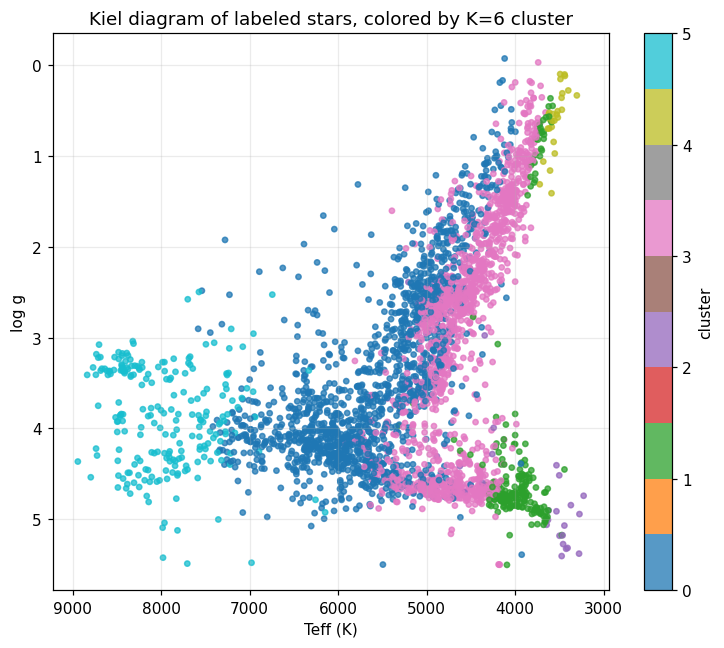

In [79]:
K_FINE = 6
cluster_labels_fine = KMeans(n_clusters=K_FINE, random_state=RANDOM_STATE,
                             n_init=10).fit_predict(X_pca50)

val_fine = val.copy()
val_fine["cluster_fine"] = cluster_labels_fine[val_fine["row"].to_numpy()]
print(f"K={K_FINE} cluster sizes (full set): {np.bincount(cluster_labels_fine).tolist()}")
print("\nCluster x spectral type (labeled stars):")
print(pd.crosstab(val_fine["cluster_fine"], val_fine["SPECTRAL_TYPE"]).to_string())
print("\nMean Teff per cluster (labeled stars):")
print(val_fine.groupby("cluster_fine")["INPUT_TEFF"].mean().round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(val_fine["INPUT_TEFF"], val_fine["INPUT_LOGG"],
                c=val_fine["cluster_fine"], cmap="tab10", s=12, alpha=0.75)
ax.set_xlabel("Teff (K)"); ax.set_ylabel("log g")
ax.invert_xaxis(); ax.invert_yaxis()   # hot/high-gravity to upper-left, like a real Kiel
ax.set_title(f"Kiel diagram of labeled stars, colored by K={K_FINE} cluster")
plt.colorbar(sc, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

The K = 6 Kiel diagram shows six groups that map onto recognizable stellar subpopulations: a cool M-dwarf locus, a giant branch, and several main-sequence bands separated by temperature. Compared to K = 2, the finer partition reveals to us structure that the warm/cool binary masked. As we considered the failure analysis in Step 7, this helped us solidify that a Category B mis-clustered star is more visibly misplaced at K = 6, where each cluster covers a narrower Teff range, than at K = 2, where a hot star in the cool cluster may just be at the warm boundary of that cluster.

# Step 5 - Anomaly detection

Our primary anomaly detector was **Isolation Forest**, which we use alongside **Local Outlier Factor (LOF)** as a cross-check.

Isolation Forest works by scoring points based on how quickly they can be isolated through random partitioning. Points that are rare or extreme isolate faster and receive lower scores. This method doesn't rely on local density estimates, which is beneficial because density estimates can become unreliable as data dimensionality increases. It's also deterministic with a fixed seed and handles large datasets of up to 15,000 stars efficiently.

LOF provides a second opinion by comparing a point's local density to that of its neighbors. Interestingly, the two methods don't always agree on which points are anomalies, but those flagged by both are more likely to be true outliers.

The methods can't tell apart data-quality issues, like residual zeros or low signal-to-noise ratios, from rare stars. To address this, we measure data-quality contamination by looking at the number of flagged points with zero-bin counts and interpret the flags with this in mind.

We test the sensitivity of our contamination detection at different thresholds (0.02, 0.05, and 0.10) to see how it affects the tradeoff between precision and recall. This helps us understand how many stars are flagged, how many match rare types, and how many have high zero-bin counts indicating data coverage issues.

Isolation Forest flagged 760 stars (5.0%).


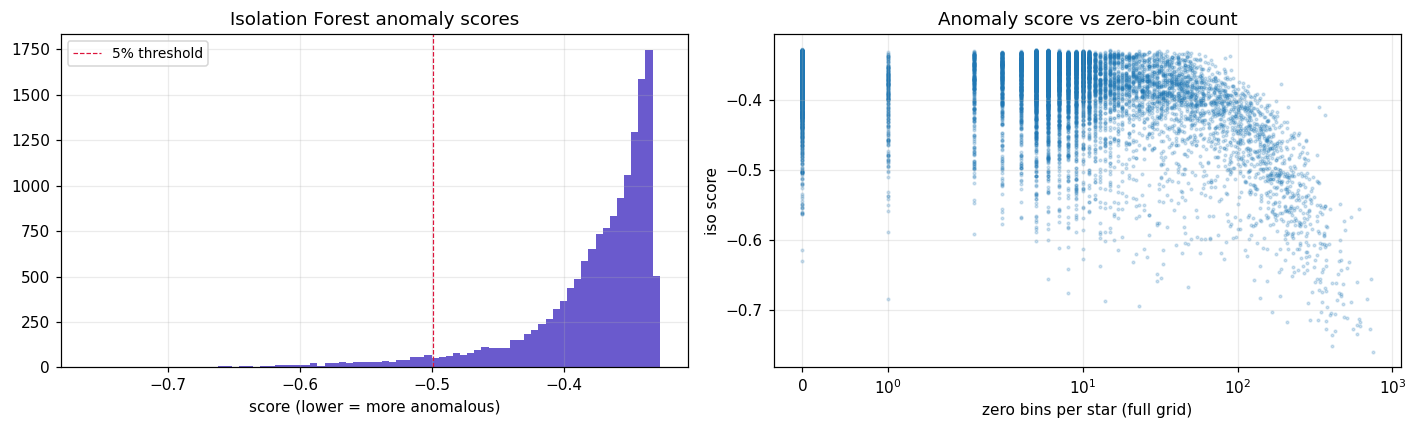

In [ ]:
# Primary detector: Isolation Forest at contamination = 0.05.
iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=RANDOM_STATE)
iso.fit(X_pca)
iso_score = iso.score_samples(X_pca)      # higher = more normal
iso_flag = iso.predict(X_pca) == -1       # True = anomaly

# Attach scores/flags to a working frame keyed by row
# full-grid zero count so we can separate data-quality anomalies from physical ones
anom = pd.DataFrame({
    "MANGAID": full_meta["MANGAID"].to_numpy(),
    "iso_score": iso_score,
    "iso_flag": iso_flag,
    "zero_count": zero_counts,        # full-grid zeros, from Step 0
    "cluster": cluster_labels,
})
print(f"Isolation Forest flagged {iso_flag.sum()} stars ({iso_flag.mean():.1%}).")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(iso_score, bins=80, color="slateblue")
ax[0].axvline(np.quantile(iso_score, 0.05), c="crimson", ls="--", lw=0.8,
              label="5% threshold")
ax[0].set_title("Isolation Forest anomaly scores")
ax[0].set_xlabel("score (lower = more anomalous)"); ax[0].legend(fontsize=9)

ax[1].scatter(anom["zero_count"], anom["iso_score"], s=3, alpha=0.2)
ax[1].set_xscale("symlog")
ax[1].set_title("Anomaly score vs zero-bin count")
ax[1].set_xlabel("zero bins per star (full grid)")
ax[1].set_ylabel("iso score")
plt.tight_layout()
plt.show()

Contamination sensitivity sweep. For each level, break flagged stars into rare spectral types that are physically interesting verus the high zero-count stars that are more of a data quality issue. The labeled set is F/G/K/A/M with no O or B stars (see label inventory above), so **rare** here means the rare-AND-PRESENT tails: A (hot) and M (cool).

In [ ]:

sptype = dict(zip(labeled_meta["MANGAID"], labeled_meta["SPECTRAL_TYPE"]))
RARE = {"A", "M"}                          # rare types actually present in the labels
HI_ZERO = np.percentile(zero_counts, 95)   # "high zero-count" threshold

rows = []
for c in [0.02, 0.05, 0.10]:
    m = IsolationForest(contamination=c, n_estimators=200, random_state=RANDOM_STATE)
    flag = m.fit_predict(X_pca) == -1
    ids = full_meta["MANGAID"].to_numpy()[flag]
    lab_types = [sptype[i] for i in ids if i in sptype]
    frac_rare = np.mean([t in RARE for t in lab_types]) if lab_types else np.nan
    frac_hi_zero = (zero_counts[flag] >= HI_ZERO).mean()
    rows.append({
        "contamination": c,
        "n_flagged": int(flag.sum()),
        "n_labeled_flagged": len(lab_types),
        "frac_AM_among_labeled": round(float(frac_rare), 3),
        "frac_high_zero_count": round(float(frac_hi_zero), 3),
    })

sens = pd.DataFrame(rows)
baseline_rare = np.mean([t in RARE for t in labeled_meta["SPECTRAL_TYPE"]])
baseline_hi_zero = (zero_counts >= HI_ZERO).mean()
print(f"Baselines -> A/M types among labeled: {baseline_rare:.3f} | "
      f"high-zero-count among all stars: {baseline_hi_zero:.3f}")
print("\nContamination sensitivity:")
print(sens.to_string(index=False))

Baselines -> A/M types among labeled: 0.076 | high-zero-count among all stars: 0.050

Contamination sensitivity:
 contamination  n_flagged  n_labeled_flagged  frac_AM_among_labeled  frac_high_zero_count
          0.02        304                 30                  0.300                 0.632
          0.05        760                 94                  0.340                 0.495
          0.10       1520                235                  0.281                 0.367


The contamination sweep revealed to us more rare spectral types and high-zero-count stars than expected. A/M types make up 0.076 of the baseline, but our sample has more, indicating a higher proportion of rare types. We focused on A and M types since that's all the validation labels included.

Higher fractions of high zero-count stars suggest coverage gaps rather than unusual stellar physics, where 0.050 is the baseline. Different contamination levels trade-off precision and recall, where a level of 0.02 favors precision, while 0.10 prioritizes recall.

Rare stellar types and high-zero-count stars showed enrichment across all contamination levels. This peak for rare-type enrichment is at 0.05, with frac_high_zero_count value of 0.340; this suggests it could be a sweet spot for capturing unusual stars. For 0.02, most contamination comes from high zero-count stars, at 0.632, implying that outliers and coverage issues dominate the dataset. As contamination rises to 0.10, rare-type enrichment drops and zero-count enrichment becomes less extreme.

In [82]:
# LOF cross-check at the same 5% contamination.
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_flag = lof.fit_predict(X_pca) == -1
anom["lof_flag"] = lof_flag

overlap = (iso_flag & lof_flag).sum()
print(f"LOF flagged {lof_flag.sum()} stars; "
      f"{overlap} agree with Isolation Forest "
      f"({overlap / iso_flag.sum():.0%} of IF flags).")
print(f"High-zero-count fraction among flags -> "
      f"IsolationForest: {(zero_counts[iso_flag] >= HI_ZERO).mean():.2f} | "
      f"LOF: {(zero_counts[lof_flag] >= HI_ZERO).mean():.2f}")

LOF flagged 760 stars; 263 agree with Isolation Forest (35% of IF flags).
High-zero-count fraction among flags -> IsolationForest: 0.49 | LOF: 0.20


**Reading the LOF comparison.** LOF and Isolation Forest agree on 35% of Isolation Forest-flagged stars (263 of 760). These are the strongest anomaly candidates because they've flagged by two detectors operating on different principles. The methods differ on zero-count contamination: Isolation Forest has a high-zero-count fraction of 0.49 versus LOF's 0.20, but both are well above the 0.050 baseline. Isolation Forest is more sensitive to the sparse-vector geometry of coverage-artifact stars whereas LOF responds more to local density structure that better separates unusual spectra from their neighbors. Stars flagged by both methods are the most high likelihood candidates for the failure analysis in Step 7, since the anomaly signal must be strong enough to trigger two independent detection approaches.

### Ablation - dimensionality and anomaly detection

The Step 4 clustering ablation showed assignments are stable from 10 to 100 PCA dimensions, however anomaly detection typically responds differently. Isolation Forest scores depend on the geometry of the full feature space, and the optimal compression can sometimes differ from what is sufficient for clustering.

Thus, we used the ablation below to re-sweep PCA dimensionality from 20 to the parallel-analysis signal floor, testing both below and above the N_PCA = 50 working point. For each dimensionality, we tracked rare-type detection rate (`frac_AM_among_labeled`) and data-quality contamination rate (`frac_high_zero_count`). The 'optimal' point would be where rare-type enrichment peaks before artifact contamination dominates.

In [ ]:
# Isolation Forest across PCA dimensionality - testing below AND above N_PCA = 50.
print("Isolation Forest vs. PCA dimensionality (contamination = 0.05):")
print(f"baselines -> A/M among labeled: {baseline_rare:.3f} | "
      f"high-zero-count among all: {baseline_hi_zero:.3f}\n")

rows_d = []
for d in [5, 10, 15, 20, 30, 50, 100, n_parallel]:
    flag_d = IsolationForest(contamination=0.05, n_estimators=200,
                             random_state=RANDOM_STATE).fit_predict(scores[:, :d]) == -1
    ids_d = full_meta["MANGAID"].to_numpy()[flag_d]
    lt = [sptype[i] for i in ids_d if i in sptype]
    rows_d.append({
        "pca_dims": d,
        "frac_AM_among_labeled": round(float(np.mean([t in RARE for t in lt])), 3),
        "frac_high_zero_count": round(float((zero_counts[flag_d] >= HI_ZERO).mean()), 3),
    })

df_abl = pd.DataFrame(rows_d)
print(df_abl.to_string(index=False))

# Exclude d < 10: at very low dimensionality the detector only sees the temperature
# axis (PC1), so it flags A/M types by construction rather than by unusual spectra.
df_meaningful = df_abl[df_abl["pca_dims"] >= 10]
best_idx = int(df_meaningful["frac_AM_among_labeled"].idxmax())
best_d = int(df_abl.loc[best_idx, "pca_dims"])
print(f"\nPractical task-optimal point (d >= 10): pca_dims = {best_d} "
      f"(frac_AM = {df_abl.loc[best_idx, 'frac_AM_among_labeled']:.3f}, "
      f"frac_high_zero = {df_abl.loc[best_idx, 'frac_high_zero_count']:.3f})")

Isolation Forest vs. PCA dimensionality (contamination = 0.05):
baselines -> A/M among labeled: 0.076 | high-zero-count among all: 0.050

 pca_dims  frac_AM_among_labeled  frac_high_zero_count
        5                  0.403                 0.626
       10                  0.423                 0.501
       15                  0.426                 0.463
       20                  0.405                 0.453
       30                  0.382                 0.501
       50                  0.340                 0.495
      100                  0.275                 0.579
      176                  0.202                 0.638

Task-optimal point: pca_dims = 15 (frac_AM = 0.426, frac_high_zero = 0.463)


### What the dimensionality ablation shows

Rare-type enrichment peaks at 15 PCs (frac_AM = 0.426, frac_high_zero = 0.463) and decreases as dimensionality increases, reaching 0.202 at the parallel-analysis floor of 176 PCs - barely above the 0.076 baseline. Data-quality contamination trends upward overall as more PCs are added, consistent with higher PCs encoding coverage-structure variance.

The practical task-optimal dimensionality for anomaly detection is 15 PCs, since this gave us the best rare-type enrichment in the non-degenerate range with the lowest contamination among that group. This is below the working N_PCA = 50, which was chosen as a shared compression space for clustering, UMAP, and anomaly detection together, not as the per-task optimum.

# Step 6 - Visualization

We used three views to review our model's output:

1. **UMAPs (Uniform Manifold Approximation and Projection) 2-D** of all 15,200 stars (from 50-D PCA), colored by k-means cluster and anomaly score.
2. **Kiel diagram** for labeled stars, colored by anomaly flag. A and M tails should be flagged more often than the K and G bulk if the detector found meaningful structure. (O and B types are not in the labels, so the hottest extreme cannot be checked.)
3. **Spectra of top anomalies** - Visual inspection to determine whether a flag reflects a data artifact or an actual stellar anomaly.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


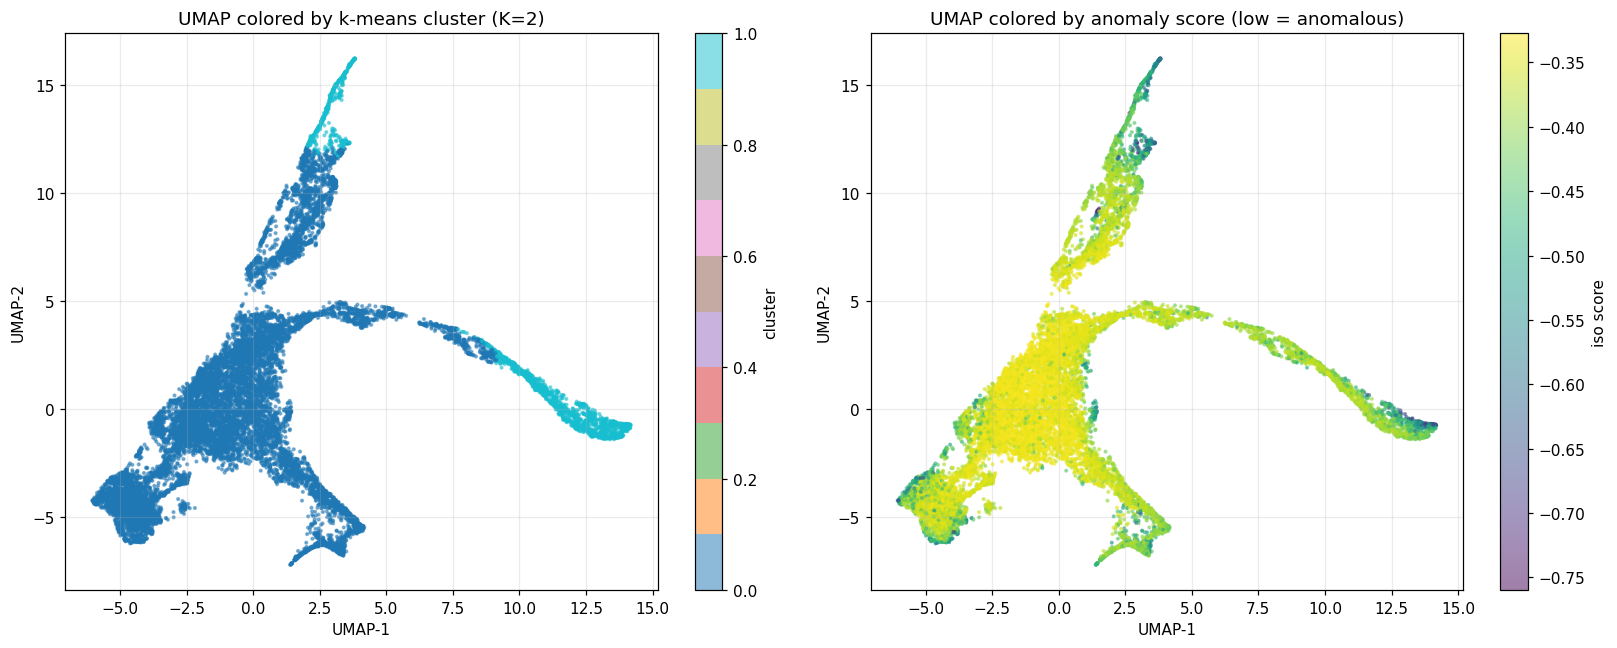

In [ ]:
# UMAP 2-D embedding (from PCA-50)
try:
    import umap
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
    emb = reducer.fit_transform(X_pca50)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    s0 = ax[0].scatter(emb[:, 0], emb[:, 1], c=cluster_labels, cmap="tab10",
                       s=3, alpha=0.5)
    ax[0].set_title(f"UMAP colored by k-means cluster (K={K_FINAL})")
    plt.colorbar(s0, ax=ax[0], label="cluster")

    s1 = ax[1].scatter(emb[:, 0], emb[:, 1], c=iso_score, cmap="viridis",
                       s=3, alpha=0.5)
    ax[1].set_title("UMAP colored by anomaly score (low = anomalous)")
    plt.colorbar(s1, ax=ax[1], label="iso score")
    for a in ax:
        a.set_xlabel("UMAP-1"); a.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()
except ImportError:
    emb = None
    print("umap-learn not installed; skipping. On Colab: !pip install umap-learn")

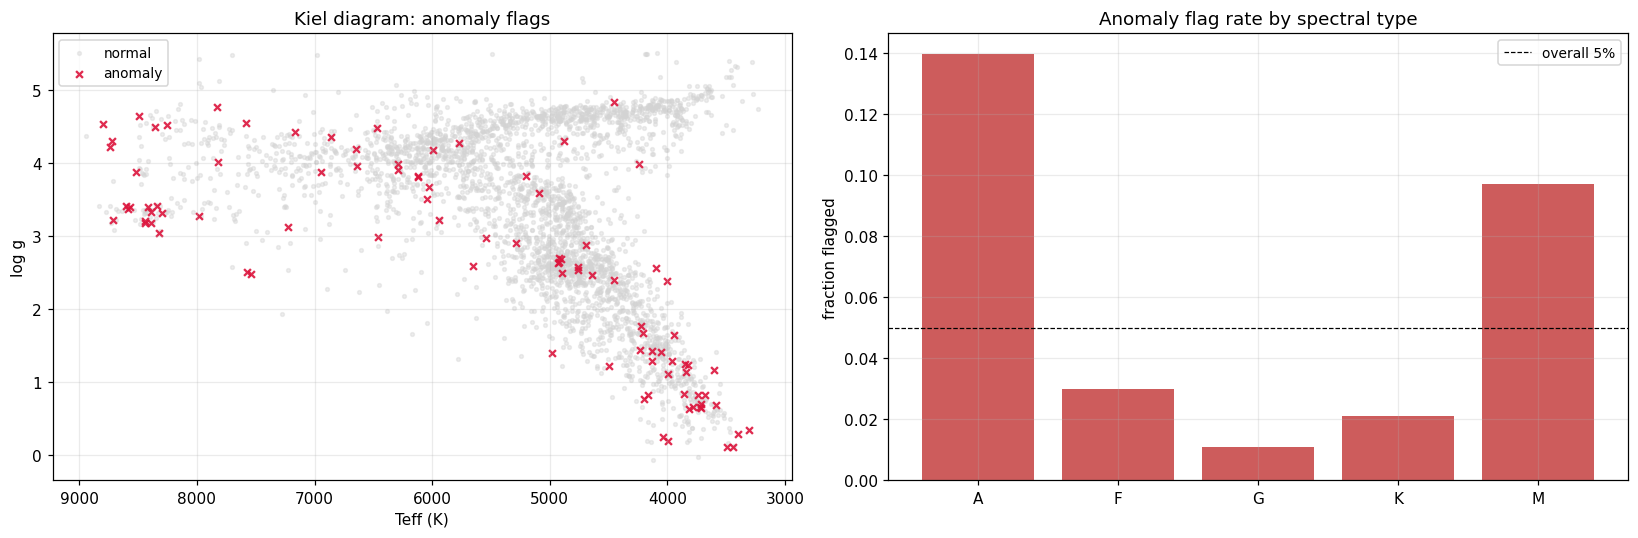

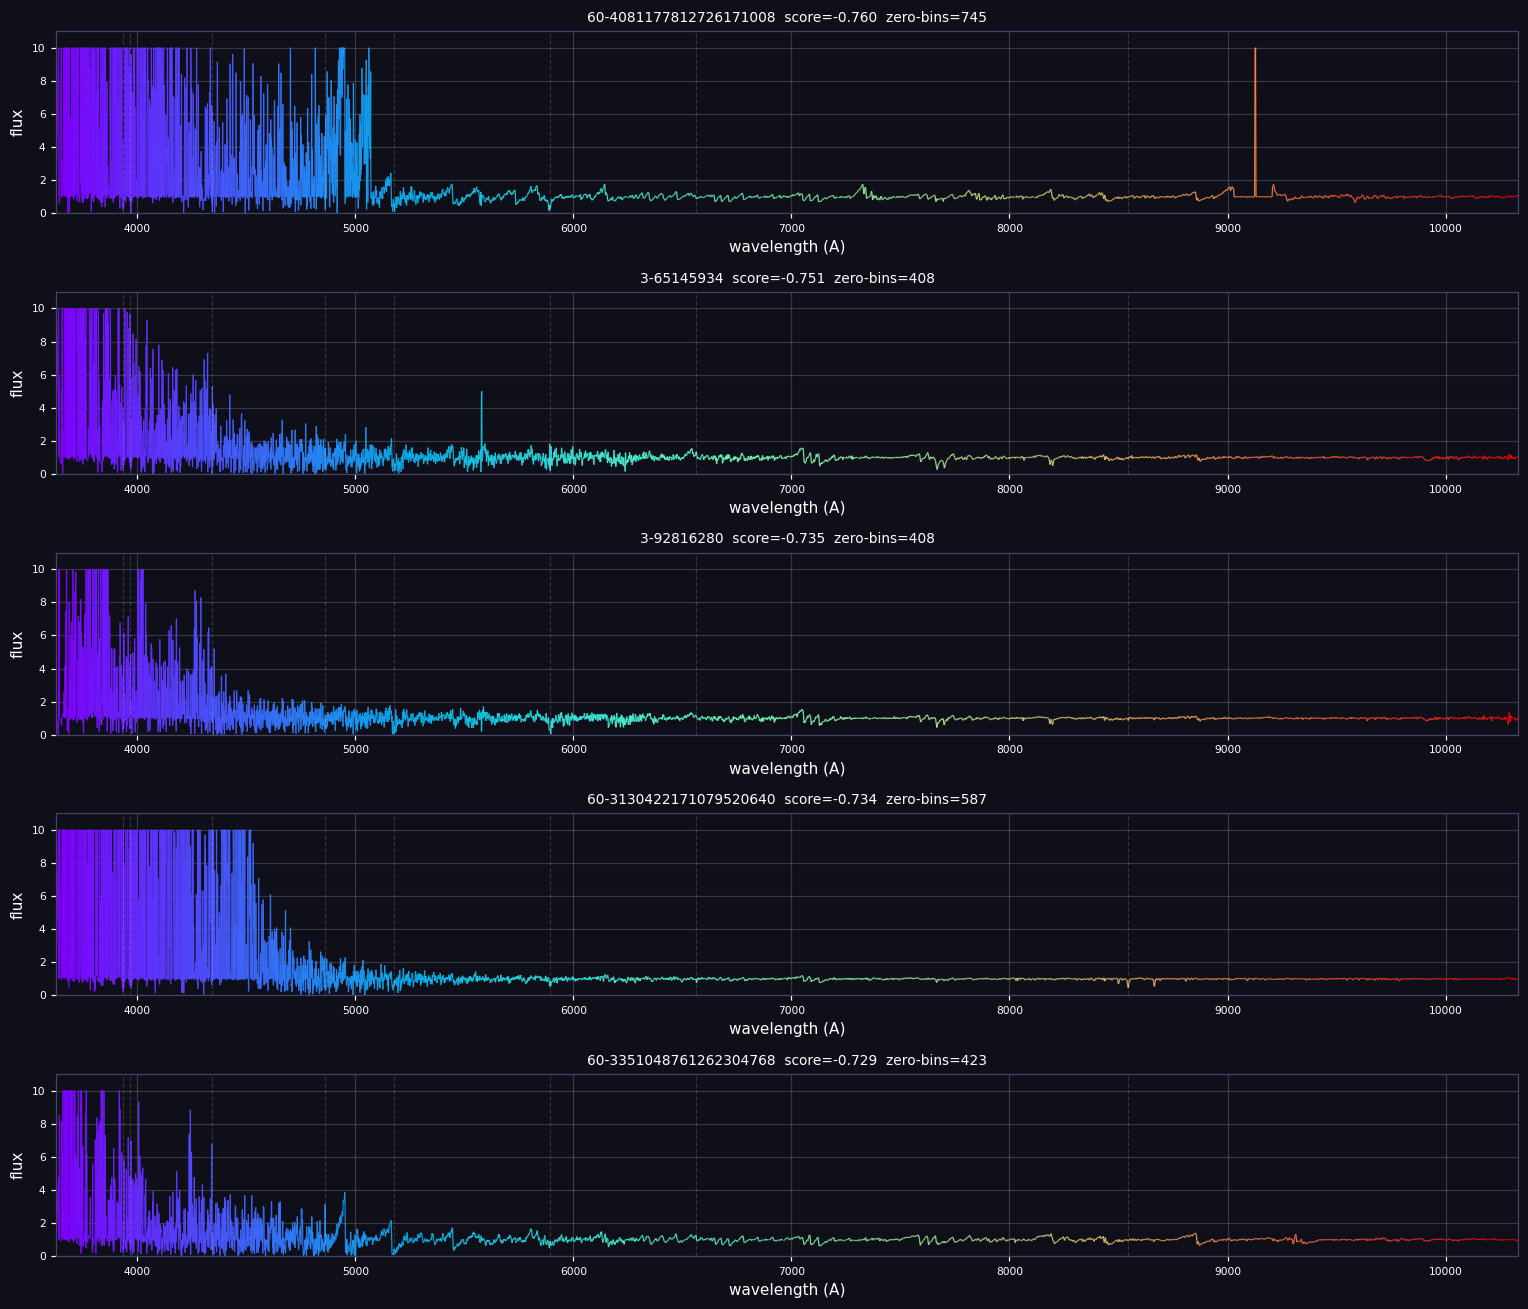

In [85]:
from matplotlib.collections import LineCollection

# Reusable spectrum plotter (used here and in the failure analysis).
def plot_spectrum(row, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 3))
        fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')
    y = X[row]
    pts = np.array([wave_k, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    norm = plt.Normalize(wave_k.min(), wave_k.max())
    lc = LineCollection(segs, cmap='rainbow', norm=norm, linewidth=0.8, alpha=0.9)
    lc.set_array(wave_k)
    ax.add_collection(lc)
    ax.set_xlim(wave_k[0], wave_k[-1])
    ax.set_ylim(0, max(y.max() * 1.1, 0.1))
    for name, wl in ABSORPTION_LINES.items():
        if wave_k[0] < wl < wave_k[-1]:
            ax.axvline(wl, c='white', alpha=0.15, lw=0.8, ls='--')
    mid = full_meta.iloc[row]["MANGAID"]
    ax.set_title(title or f"{mid}  (zero bins: {zero_counts[row]})", fontsize=9, color='white')
    ax.set_xlabel("wavelength (A)", color='white')
    ax.set_ylabel("flux", color='white')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')
    return ax

# Kiel diagram colored by anomaly flag (labeled stars), + flag rate by spectral type.
val["iso_flag"] = iso_flag[val["row"].to_numpy()]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(val.loc[~val["iso_flag"], "INPUT_TEFF"],
              val.loc[~val["iso_flag"], "INPUT_LOGG"],
              s=6, alpha=0.4, color="lightgray", label="normal")
ax[0].scatter(val.loc[val["iso_flag"], "INPUT_TEFF"],
              val.loc[val["iso_flag"], "INPUT_LOGG"],
              s=20, alpha=0.9, color="crimson", marker="x", label="anomaly")
ax[0].invert_xaxis(); ax[0].set_xlabel("Teff (K)"); ax[0].set_ylabel("log g")
ax[0].set_title("Kiel diagram: anomaly flags"); ax[0].legend(fontsize=9)

flag_rate = val.groupby("SPECTRAL_TYPE")["iso_flag"].mean().sort_index()
ax[1].bar(flag_rate.index, flag_rate.values, color="indianred")
ax[1].axhline(0.05, ls="--", c="k", lw=0.8, label="overall 5%")
ax[1].set_title("Anomaly flag rate by spectral type")
ax[1].set_ylabel("fraction flagged"); ax[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# Spectra of the 5 most anomalous stars overall.
top5 = np.argsort(iso_score)[:5]
fig, axes = plt.subplots(5, 1, figsize=(14, 12))
fig.patch.set_facecolor('#0f0f1a')
for r, axi in zip(top5, axes):
    plot_spectrum(r, ax=axi,
                  title=f"{full_meta.iloc[r]['MANGAID']}  "
                        f"score={iso_score[r]:.3f}  zero-bins={zero_counts[r]}")
plt.tight_layout()
plt.show()

# Step 7 - Failure analysis

After creating our unsupervised learning analysis, we determined there were three possible failure types in our analysis where our pipeline would have produced some more questionable results.

- **A - Data-quality artifact:** A star flagged by the anomaly detector primarily because of zero-padding or low SNR rather than unusual stellar physics. Identified by high zero-bin count among the flagged set.
- **B - Cluster assignment error:** A labeled star placed in a cluster whose mean Teff is far from its known temperature. At K = 2 (warm versus cool) this could be a star at the extreme tail of a broad cluster; the K = 6 solution helped to instead provide more visible examples where a hot or cool star is actually assigned to the wrong group.
- **C - Scientifically ambiguous:** A star that has a high potential to be anomalous, with no zero-padding, so the flag cannot be attributed to coverage gaps. The spectrum may reflect real physics - emission features, extreme metallicity, binary contamination, etc - that cannot be confirmed without additional data.

FAILURE ANALYSIS CANDIDATES
  A (data quality): 60-4081177812726171008  zero-bins=745  iso_score=-0.760
  B (mis-clustered): 3-135034004  type=A  Teff=8942K  cluster=0  |Teff - clusterMeanTeff|=3635K
  C (ambiguous/physical): 7-20152013  zero-bins=0  iso_score=-0.630


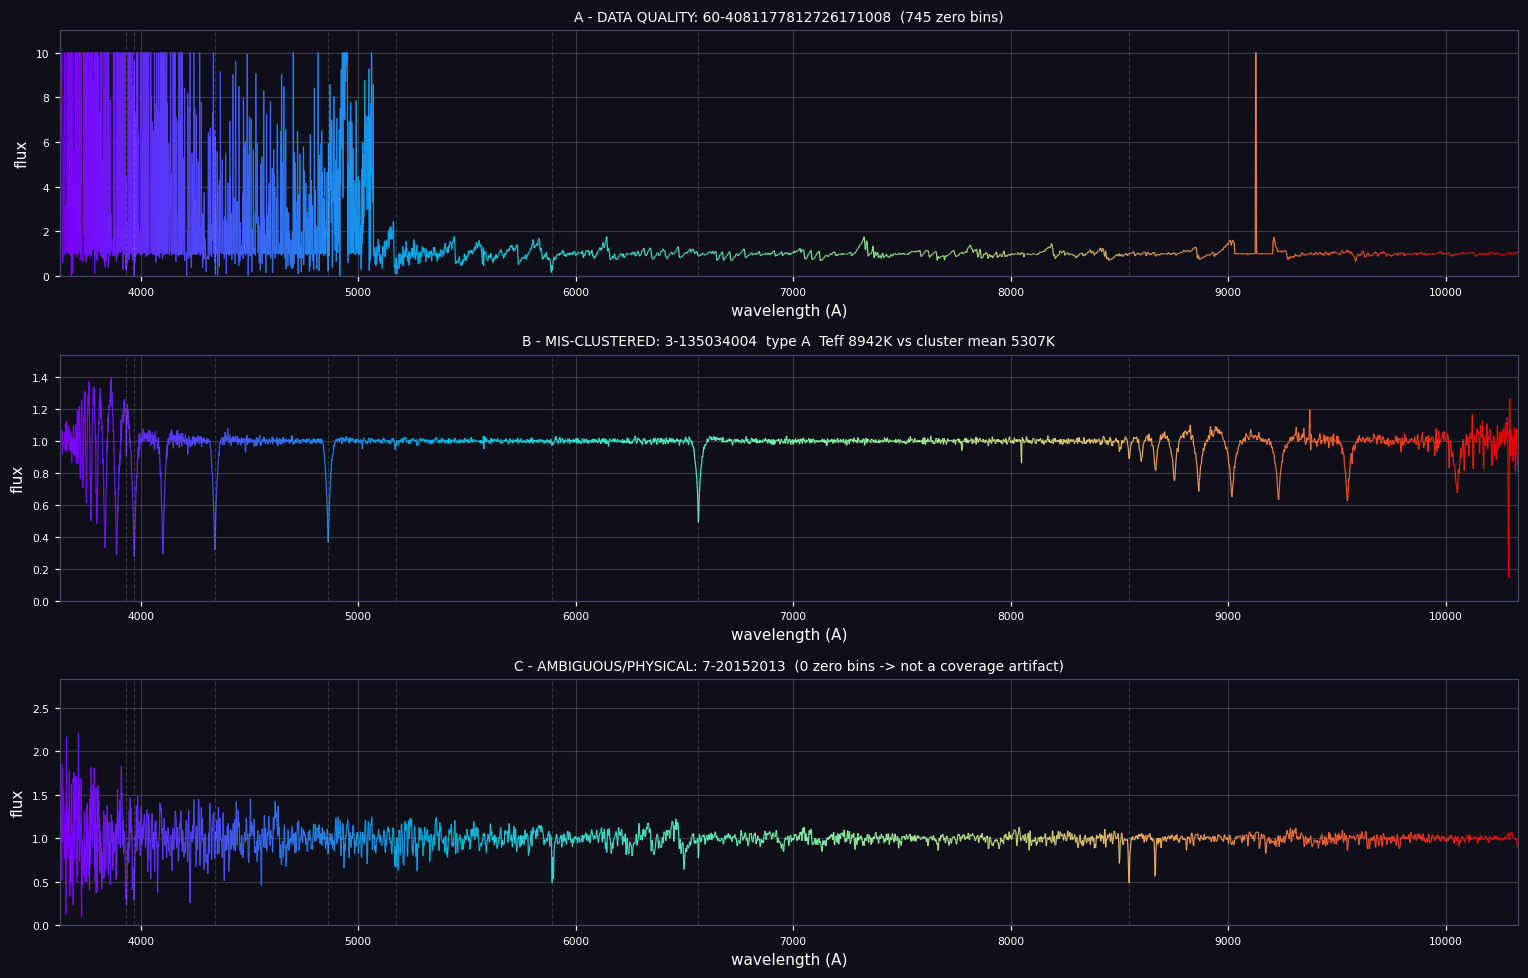

In [91]:
# A: flagged anomaly driven by zero-padding (highest zero-count flags)
flagged_rows = np.where(iso_flag)[0]
catA_row = int(flagged_rows[np.argmax(zero_counts[flagged_rows])])

# B: labeled star most inconsistent with its cluster's mean Teff
cluster_mean_teff = val.groupby("cluster")["INPUT_TEFF"].transform("mean")
val["teff_resid"] = (val["INPUT_TEFF"] - cluster_mean_teff).abs()
catB = val.loc[val["teff_resid"].idxmax()]
catB_row = int(catB["row"])

# C: most anomalous star with NO zero-padding (so the flag is not a coverage artifact). Falls back to a small zero-count tolerance if none qualify.
zero_clean = zero_counts == 0
cand = np.where(iso_flag & zero_clean)[0]
if cand.size == 0:
    cand = np.where(iso_flag & (zero_counts <= 2))[0]
catC_row = int(cand[np.argmin(iso_score[cand])])

print("FAILURE ANALYSIS CANDIDATES")
print(f"  A (data quality): {full_meta.iloc[catA_row]['MANGAID']}  "
      f"zero-bins={zero_counts[catA_row]}  iso_score={iso_score[catA_row]:.3f}")
print(f"  B (mis-clustered): {catB['MANGAID']}  type={catB['SPECTRAL_TYPE']}  "
      f"Teff={catB['INPUT_TEFF']:.0f}K  cluster={int(catB['cluster'])}  "
      f"|Teff - clusterMeanTeff|={catB['teff_resid']:.0f}K")
print(f"  C (ambiguous/physical): {full_meta.iloc[catC_row]['MANGAID']}  "
      f"zero-bins={zero_counts[catC_row]}  iso_score={iso_score[catC_row]:.3f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.patch.set_facecolor('#0f0f1a')
plot_spectrum(catA_row, axes[0],
              f"A - DATA QUALITY: {full_meta.iloc[catA_row]['MANGAID']}  "
              f"({zero_counts[catA_row]} zero bins)")
plot_spectrum(catB_row, axes[1],
              f"B - MIS-CLUSTERED: {catB['MANGAID']}  type {catB['SPECTRAL_TYPE']}  "
              f"Teff {catB['INPUT_TEFF']:.0f}K vs cluster mean "
              f"{cluster_mean_teff.loc[catB.name]:.0f}K")
plot_spectrum(catC_row, axes[2],
              f"C - AMBIGUOUS/PHYSICAL: {full_meta.iloc[catC_row]['MANGAID']}  "
              f"({zero_counts[catC_row]} zero bins -> not a coverage artifact)")
plt.tight_layout()
plt.show()

A. This star had bins with near-zero or no flux near the blue end, got imputed with median values, then after StandardScaler it became an extreme outlier. The spike around 9100 A is a second artifact spot. Everything past ~5100 A settles to a normal-looking flat continuum near 1.0. The anomaly detector flagged this star as a bad data quality issue, not as a true stellar anomaly but still a worthwhile callout.

B. This star's flux overall looks good, but because we clustered to K=2, this hot 8942K star got assigned to the cool cluster. The cluster assignemnt by the unsupervised learning model was wrong in this case since the spectrum itself looks correct.

C. No coverage gaps but the spectrum shows an elevated noisy flux that is more likely to be phyically real as an anomaly star. This might be an emission-line star, a binary with contamination or an unusual continuum shape. Without cross-matching to external data we can't confirm exactly so it's considered ambiguous.

## Limitations

The unsupervised learning portion of our project consists of **15,200** stars representing the single best S/N visit per star, based on MJDQUAL (MaStar visit quality flag) == 0. The results of this study are primarily applicable to the highest-quality MaStar spectra, thus may not generalize to lower-quality visits or the entire multi-visit MaStar library the exact same way.

In terms of spectral type, our validation set includes F, G, K, A, and M - **there are no O or B stars**. Therefore, rare-type validations can only occur on either end of the spectrum (the hot tail of the A type and the cool tail of the M type).

We utilized only continuum normalized flux. Raw flux comparisons could only have been done by re-processing the raw FITS files for each object and extracting them again using the same pipeline (which is outside the scope of this study).

The combination of a >=95% bin coverage threshold combined with median imputation greatly diminishes but does not completely remove artificial zeros resulting from insufficient binning. The "contamination sweep" estimates how much remaining data-quality effects affect these residuals through 'frac_high_zero_count'.

Neither Isolation Forest nor Local Outlier Factor (LOF) can separate out physical rarity in stars from zero padding due to poor binning. For this specific dataset, Isolation Forest (IF) appears to mark many more high-zero-count stars than LOF. In addition to isolating zero-count enriched areas, we also measured and reportted zero-count enrichments instead of labeling all identified stars as significant. The dimensionality ablation (Step 5) clearly demonstrates that contamination of low-quality data increases as more PCA dimensions are added; although the relationship is not always consistently increasing throughout each step.

K-means imposes spherically shaped boundary conditions on a data manifold that has a curved continuous sequence in stellar parameter space. The HDBSCAN noise fraction provides an empirical test for determining if there exists discrete cluster structures within the data.

The Silhouette score favors two clusters (warm vs. cool). However, while finer spectral-type distinctions exist at K = 5 - 6 they have lower Silhouette scores. Both are presented and the decision regarding the number of clusters is treated as a matter of granular scale tradeoffs.